# Sumatranomics 2026 - Notebook 02
## Estimasi Struktur Keterkaitan Antar Variabel Sosial Ekonomi Sumatera Utara

Notebook 01 menghasilkan tabel bersih. Notebook ini mencari angka angkanya: seberapa besar satu variabel
menggerakkan variabel lain, berapa lama pengaruh itu berjalan, dan seberapa yakin kita terhadap angka
tersebut. Hasilnya adalah tabel parameter yang menjadi masukan langsung bagi model dinamika sistem di
notebook 03.

Prinsip yang dipegang di sini hanya satu. Parameter model dinamika sistem harus diestimasi dari data,
bukan diasumsikan. Banyak model dinamika sistem regional di Indonesia menetapkan koefisiennya lewat
kesepakatan pakar atau lewat kalibrasi coba coba sampai keluarannya terlihat masuk akal. Cara itu membuat
model tidak dapat disalahkan oleh data, dan sesuatu yang tidak dapat disalahkan tidak dapat dipercaya.
Karena itu setiap parameter di sini disertai galat baku, nilai p, dan jumlah amatan yang mendasarinya.
Parameter yang tidak terestimasi dengan presisi memadai dinyatakan demikian secara terbuka, lalu ditandai
agar notebook 03 menguji sensitivitasnya, bukan diam diam dipakai seolah olah pasti.

### Lima blok estimasi

| Blok | Pertanyaan | Data | Metode |
|---|---|---|---|
| A | Bagaimana guncangan harga menjalar di tingkat provinsi | 79 bulan, 2020 sampai 2026 | Johansen, VAR, proyeksi lokal |
| B | Seberapa cepat harga antar kabupaten menyatu kembali | 84 ribu amatan harga bulanan | Model koreksi galat per wilayah |
| C | Apakah petani menambah luas tanam ketika harga naik | Panel tahunan kabupaten | Respons penawaran Nerlove |
| D | Bagaimana harga pangan berubah menjadi kemiskinan | Panel tahunan kabupaten | Regresi beda pertama berkelompok |
| E | Seberapa besar limpahan antar wilayah yang berdekatan | Panel bulanan dan tahunan | Moran I, model spatial lag |

### Prasyarat

Notebook 01 harus sudah dijalankan sampai selesai, dan folder keluarannya harus berada pada lokasi yang
sama. Notebook ini tidak membaca berkas Excel sumber sama sekali. Seluruh masukannya berasal dari tabel
hasil notebook 01, sehingga bila ada perbedaan angka, penelusurannya cukup pada satu titik.

---
## Bagian 1. Konfigurasi dan pembacaan keluaran notebook 01

In [1]:
# Sel 1.1 - Pustaka dan lingkungan

import importlib, subprocess, sys

WAJIB = {"pandas": "pandas>=2.0", "numpy": "numpy>=1.24", "scipy": "scipy>=1.10",
         "matplotlib": "matplotlib>=3.7", "statsmodels": "statsmodels>=0.14"}

def pastikan(paket_map, wajib=True):
    hilang = []
    for modul, spek in paket_map.items():
        try:
            importlib.import_module(modul)
        except ImportError:
            hilang.append((modul, spek))
    for modul, spek in hilang:
        print("Memasang", spek)
        kode = subprocess.call([sys.executable, "-m", "pip", "install", "-q", spek])
        if kode != 0:
            kode = subprocess.call([sys.executable, "-m", "pip", "install", "-q",
                                    "--break-system-packages", spek])
        if kode != 0 and wajib:
            raise RuntimeError("Gagal memasang " + spek)
    return hilang

pastikan(WAJIB)

import pandas as pd, numpy as np, matplotlib, os, re, json, warnings, platform
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, select_order
from pathlib import Path
from datetime import datetime
warnings.filterwarnings("ignore")

print("Python     :", sys.version.split()[0])
print("pandas     :", pd.__version__)
print("numpy      :", np.__version__)
print("statsmodels:", __import__("statsmodels").__version__)

Python     : 3.11.14
pandas     : 2.2.3
numpy      : 2.1.3
statsmodels: 0.14.6


In [2]:
# Sel 1.2 - Penentuan folder dan pembacaan tabel notebook 01

NAMA_PROYEK = "Sumatranomics_2026_Sumut"

def cari_folder(nama_awalan, kedalaman=4):
    akar = Path.cwd().resolve()
    kandidat = []
    for _ in range(kedalaman):
        kandidat.append(akar)
        if akar.parent == akar:
            break
        akar = akar.parent
    for basis in kandidat:
        for p in sorted(basis.glob(nama_awalan + "*")):
            if p.is_dir() and (p / "tabel").is_dir():
                return p
        for p in sorted(basis.glob("*/" + nama_awalan + "*")):
            if p.is_dir() and (p / "tabel").is_dir():
                return p
    return None

DIR_NB01 = cari_folder("Keluaran_" + NAMA_PROYEK)
if DIR_NB01 is None:
    raise FileNotFoundError(
        "Folder keluaran Notebook 01 tidak ditemukan. Jalankan Notebook 01 lebih dahulu, "
        "atau tetapkan DIR_NB01 secara manual pada sel ini.")
print("Masukan dari :", DIR_NB01)

DIR_KELUARAN = DIR_NB01.parent / ("Keluaran_" + NAMA_PROYEK + "_NB02")
for sub in ["tabel", "gambar", "mutu", "log"]:
    (DIR_KELUARAN / sub).mkdir(parents=True, exist_ok=True)
print("Keluaran ke  :", DIR_KELUARAN)


def cari_google_drive():
    rumah = Path.home()
    sistem = platform.system()
    pola = []
    if sistem == "Darwin":
        pola += [rumah / "Library" / "CloudStorage", Path("/Volumes/GoogleDrive"), rumah / "Google Drive"]
    elif sistem == "Windows":
        for huruf in "GHIJKDEF":
            pola += [Path(huruf + ":/My Drive"), Path(huruf + ":/")]
        pola += [rumah / "Google Drive", rumah / "GoogleDrive"]
    else:
        pola += [rumah / "GoogleDrive", rumah / "gdrive", Path("/content/drive/MyDrive")]
    for p in pola:
        if not p.exists():
            continue
        if p.name == "CloudStorage":
            for anak in sorted(p.glob("GoogleDrive-*")):
                for sub in ["My Drive", "Drive Saya"]:
                    if (anak / sub).is_dir():
                        return anak / sub
            continue
        for sub in ["My Drive", "Drive Saya", ""]:
            calon = p / sub if sub else p
            if calon.is_dir():
                return calon
    return None

DRIVE = None
if "google.colab" in sys.modules:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        DRIVE = Path("/content/drive/MyDrive")
    except Exception as e:
        print("Pemasangan Drive Colab dilewati:", e)
if DRIVE is None:
    DRIVE = cari_google_drive()

DIR_DRIVE = None
if DRIVE is not None:
    try:
        DIR_DRIVE = DRIVE / NAMA_PROYEK / ("Notebook02_" + datetime.now().strftime("%Y%m%d"))
        for sub in ["tabel", "gambar", "mutu", "log"]:
            (DIR_DRIVE / sub).mkdir(parents=True, exist_ok=True)
        print("Folder Drive :", DIR_DRIVE)
    except Exception as e:
        print("Folder Drive tidak dapat dibuat:", e)
        DIR_DRIVE = None
else:
    print("Folder Drive : tidak terdeteksi, keluaran hanya lokal")


def simpan(obj, nama_relatif, indeks=False):
    tujuan = [DIR_KELUARAN / nama_relatif]
    if DIR_DRIVE is not None:
        tujuan.append(DIR_DRIVE / nama_relatif)
    for t in tujuan:
        t.parent.mkdir(parents=True, exist_ok=True)
        obj.to_csv(t, index=indeks)
    return tujuan[0]


T = DIR_NB01 / "tabel"
REGISTRI = pd.read_csv(T / "registri_wilayah.csv", dtype={"kode_wilayah": str})
PANEL_TAHUNAN = pd.read_csv(T / "panel_tahunan_kabkota.csv", dtype={"kode_wilayah": str})
PANEL_BULANAN = pd.read_csv(T / "panel_bulanan_provinsi.csv")
IHK_KOTA = pd.read_csv(T / "panel_bulanan_ihk_kabkota.csv", dtype={"kode_wilayah": str})
HARGA = pd.read_csv(T / "panel_harga_kabupaten.csv", dtype={"kode_wilayah": str})
PENIMBANG_NTP = pd.read_csv(T / "penimbang_ntp.csv")
PENIMBANG_IHK = pd.read_csv(T / "penimbang_ihk.csv")

KODE_PROVINSI = "1200"
KAB = PANEL_TAHUNAN[PANEL_TAHUNAN.kode_wilayah != KODE_PROVINSI].copy()
KODE_KABKOTA = sorted(REGISTRI.loc[REGISTRI.kode_wilayah != KODE_PROVINSI, "kode_wilayah"])
NAMA = dict(zip(REGISTRI.kode_wilayah, REGISTRI.nama_baku))

for nama, obj in [("registri_wilayah", REGISTRI), ("panel_tahunan_kabkota", PANEL_TAHUNAN),
                  ("panel_bulanan_provinsi", PANEL_BULANAN), ("panel_bulanan_ihk_kabkota", IHK_KOTA),
                  ("panel_harga_kabupaten", HARGA), ("penimbang_ntp", PENIMBANG_NTP),
                  ("penimbang_ihk", PENIMBANG_IHK)]:
    print("  ", nama.ljust(28), str(obj.shape[0]).rjust(7), "baris x", str(obj.shape[1]).rjust(3), "kolom")

Masukan dari : /Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut
Keluaran ke  : /Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut_NB02
Folder Drive : /Users/user/Library/CloudStorage/GoogleDrive-dgiveup719@gmail.com/My Drive/Sumatranomics_2026_Sumut/Notebook02_20260830


   registri_wilayah                  34 baris x   9 kolom
   panel_tahunan_kabkota            442 baris x  82 kolom
   panel_bulanan_provinsi            79 baris x  37 kolom
   panel_bulanan_ihk_kabkota        488 baris x  11 kolom
   panel_harga_kabupaten          84397 baris x   9 kolom
   penimbang_ntp                   2641 baris x  19 kolom
   penimbang_ihk                   6272 baris x  13 kolom


In [3]:
# Sel 1.3 - Gaya visualisasi, sama persis dengan notebook 01

import matplotlib.pyplot as plt
from matplotlib import font_manager

def pilih_huruf(prioritas=("Times New Roman", "Nimbus Roman", "Liberation Serif",
                           "FreeSerif", "Tinos", "DejaVu Serif")):
    tersedia = {f.name for f in font_manager.fontManager.ttflist}
    for nama in prioritas:
        if nama in tersedia:
            return nama
    return "serif"

HURUF = pilih_huruf()
UKURAN = 13
plt.rcParams.update({
    "font.family": "serif", "font.serif": [HURUF, "DejaVu Serif"], "font.size": UKURAN,
    "axes.titlesize": UKURAN + 1, "axes.labelsize": UKURAN,
    "xtick.labelsize": UKURAN - 1, "ytick.labelsize": UKURAN - 1,
    "legend.fontsize": UKURAN - 1, "figure.titlesize": UKURAN + 2,
    "mathtext.fontset": "dejavuserif", "axes.grid": True, "grid.alpha": 0.25,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight", "savefig.pad_inches": 0.20,
    "figure.constrained_layout.use": True, "figure.constrained_layout.h_pad": 0.08,
    "figure.constrained_layout.w_pad": 0.08, "figure.constrained_layout.hspace": 0.09,
    "figure.constrained_layout.wspace": 0.09, "legend.frameon": True,
    "legend.framealpha": 0.90, "legend.edgecolor": "0.75", "axes.axisbelow": True,
})
PALET = ["#1f4e79", "#c0504d", "#4f81bd", "#9bbb59", "#8064a2",
         "#f79646", "#4bacc6", "#7f7f7f", "#2e7d32", "#ad1457"]
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALET)

KATALOG_GAMBAR = []
def simpan_gambar(fig, nama, keterangan=""):
    berkas = "gambar/" + nama + ".png"
    tujuan = [DIR_KELUARAN / berkas]
    if DIR_DRIVE is not None:
        tujuan.append(DIR_DRIVE / berkas)
    for t in tujuan:
        t.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(t)
    KATALOG_GAMBAR.append({"berkas": nama + ".png", "keterangan": keterangan})
    return tujuan[0]

PARAMETER = []
def catat_parameter(blok, nama, nilai, se=None, p=None, n=None, satuan="", metode="",
                    keterangan="", presisi=None):
    """Simpan satu parameter hasil estimasi beserta ukuran ketidakpastiannya."""
    if presisi is None:
        if se is None or nilai is None or not np.isfinite(se) or se == 0:
            presisi = "tidak diketahui"
        else:
            rasio = abs(nilai) / se
            presisi = "tinggi" if rasio >= 2.58 else ("sedang" if rasio >= 1.96 else "rendah")
    PARAMETER.append({"blok": blok, "parameter": nama, "nilai": nilai, "galat_baku": se,
                      "nilai_p": p, "n_amatan": n, "satuan": satuan, "metode": metode,
                      "presisi": presisi, "keterangan": keterangan})

print("Huruf terpilih:", HURUF, "ukuran", UKURAN)
if HURUF != "Times New Roman":
    print("Times New Roman tidak terpasang. Huruf pengganti bermetrik serif setara dipakai.")

Huruf terpilih: Times New Roman ukuran 13


In [4]:
# Sel 1.4 - Pembantu penempatan label agar tidak saling menimpa

def label_tanpa_tumpang(ax, x, y, teks, fontsize=None, warna="0.20",
                        jarak_awal=9.0, jarak_maks=38.0, garis_penunjuk=True,
                        halo=False, halo_lebar=2.2, halo_warna="white"):
    """Tempatkan label pada titik sebar tanpa saling menimpa.

    Untuk tiap titik dicoba sejumlah arah dan jarak, lalu dipilih posisi pertama yang
    kotak batasnya tidak beririsan dengan label yang sudah terpasang maupun dengan titik
    titik data. Bila seluruh calon gagal, label ditempatkan pada jarak terjauh dan
    disertai garis penunjuk tipis agar kaitannya tetap terbaca.

    Argumen halo memberi garis tepi putih tipis pada huruf. Ini diperlukan pada peta
    tematik, sebab tanpa garis tepi, tulisan gelap di atas poligon berwarna gelap tidak
    terbaca sama sekali.
    """
    import matplotlib.patheffects as pe
    efek = [pe.withStroke(linewidth=halo_lebar, foreground=halo_warna)] if halo else None
    if fontsize is None:
        fontsize = plt.rcParams["font.size"] - 4
    fig = ax.figure
    fig.canvas.draw()
    peranti = fig.canvas.get_renderer()

    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    titik_px = ax.transData.transform(np.column_stack([x, y]))
    kotak_titik = [matplotlib.transforms.Bbox.from_bounds(px - 7, py - 7, 14, 14)
                   for px, py in titik_px]

    arah = [(1, 0.30), (-1, 0.30), (1, -0.30), (-1, -0.30), (0, 1), (0, -1),
            (1, 1), (-1, 1), (1, -1), (-1, -1), (1, 0.75), (-1, 0.75), (1, -0.75), (-1, -0.75)]
    jarak = [jarak_awal, jarak_awal * 1.5, jarak_awal * 2.1, jarak_awal * 2.9, jarak_maks]

    terpasang = []
    urut = np.argsort(-y)          # dari atas ke bawah agar hasilnya rapi dan terulang
    for i in urut:
        dipilih = None
        for r in jarak:
            for dx, dy in arah:
                anot = ax.annotate(str(teks[i]), (x[i], y[i]), textcoords="offset points",
                                   xytext=(dx * r, dy * r), fontsize=fontsize, color=warna,
                                   ha="left" if dx > 0 else ("right" if dx < 0 else "center"),
                                   va="bottom" if dy > 0 else ("top" if dy < 0 else "center"),
                                   zorder=7, path_effects=efek)
                kotak = anot.get_window_extent(renderer=peranti).expanded(1.12, 1.28)
                bentrok = any(kotak.overlaps(k) for k in terpasang) \
                          or any(kotak.overlaps(k) for j, k in enumerate(kotak_titik) if j != i)
                if not bentrok:
                    dipilih = (anot, kotak); break
                anot.remove()
            if dipilih:
                break
        if dipilih is None:
            dx, dy = arah[0]; r = jarak_maks
            anot = ax.annotate(str(teks[i]), (x[i], y[i]), textcoords="offset points",
                               xytext=(dx * r, dy * r), fontsize=fontsize, color=warna,
                               ha="left", va="center", zorder=7, path_effects=efek,
                               arrowprops=dict(arrowstyle="-", color="0.45", linewidth=0.7)
                               if garis_penunjuk else None)
            dipilih = (anot, anot.get_window_extent(renderer=peranti))
        terpasang.append(dipilih[1])
    return len(terpasang)

print("Pembantu penempatan label siap dipakai.")

Pembantu penempatan label siap dipakai.


---
## Bagian 2. Geometri wilayah dan matriks pembobot spasial

Berkas batas administrasi kabupaten dan kota Sumatera Utara kini tersedia pada folder data, sehingga
seluruh perhitungan keruangan pada notebook ini bersandar pada geometri resmi, bukan pada perkiraan
koordinat ibu kota. Yang berubah bukan hanya ketelitian titik, melainkan jenis ketetanggaan yang dapat
dibentuk. Dengan poligon, ketetanggaan dapat didefinisikan sebagai berbagi batas wilayah
(*contiguity*), yaitu definisi baku dalam ekonometrika spasial, bukan sekadar kedekatan jarak.

### Peringatan penting mengenai kode wilayah

Berkas batas memakai kode Kementerian Dalam Negeri berformat 12.NN, sedangkan seluruh data statistik
dalam proyek ini memakai kode Badan Pusat Statistik berformat 12NN. Kedua sistem kode ini **tidak
identik**. Kode Kementerian Dalam Negeri mengikuti urutan historis pembentukan daerah, sedangkan kode
Badan Pusat Statistik mengikuti urutan yang berbeda. Contohnya, 12.01 pada berkas batas adalah Tapanuli
Tengah, sedangkan 1201 pada data statistik adalah Nias. Demikian pula 12.71 adalah Kota Medan pada berkas
batas, sedangkan 1271 pada data statistik adalah Kota Sibolga.

Bila kedua kode itu dipasangkan begitu saja, poligon Medan akan tertempel pada angka kemiskinan Sibolga
dan seluruh analisis keruangan akan salah tanpa memberi tanda apa pun. Karena itu pemasangan dilakukan
berdasarkan **nama wilayah yang dibakukan**, bukan berdasarkan kode. Sel di bawah mencetak tabel
perbandingan lengkap kedua sistem kode agar pembaca dapat memeriksa sendiri bahwa pemasangannya benar.

### Empat definisi ketetanggaan

**Ketetanggaan batas (*contiguity*).** Dua wilayah bertetangga bila berbagi garis batas. Inilah definisi
baku dan menjadi pembobot utama. Empat kota berstatus enklave, yaitu Pematangsiantar, Tanjungbalai,
Tebing Tinggi, dan Padangsidimpuan, tidak berbagi vertex batas dengan kabupaten yang mengelilinginya
karena poligonnya digambar terpisah. Keempatnya ditangani lewat uji titik dalam poligon, yaitu
dihubungkan dengan kabupaten yang wilayahnya memuat sentroid kota tersebut.

**Ketetanggaan jarak.** Lima wilayah terdekat menurut jarak sentroid, dihitung dengan rumus haversine.
Berguna sebagai pembanding, dan menjadi satu satunya definisi yang menghubungkan gugus Kepulauan Nias
dengan daratan.

**Ketetanggaan ekonomi.** Kemiripan gerak harga bulanan antar kabupaten, sepenuhnya terhitung dari data
proyek ini tanpa masukan geografis.

**Ketetanggaan struktur produksi.** Kemiripan komposisi produksi pertanian.

In [5]:
# Sel 2.1 - Pembacaan berkas batas wilayah tanpa memerlukan pustaka geospasial

def cari_berkas_batas(folder_awal=None):
    """Telusuri folder data untuk menemukan berkas batas kabupaten dan kota."""
    calon = []
    basis = [Path(folder_awal) if folder_awal else DIR_NB01.parent, Path.cwd()]
    pola = ["*batas*kab*.geojson", "*batas*kab*.json", "*kabupaten*.geojson",
            "*adm2*.geojson", "*sumut*.geojson", "*sumatera*utara*.geojson"]
    for b in basis:
        for p in pola:
            calon += [x for x in b.rglob(p) if x.is_file()]
    urut = sorted(set(calon), key=lambda x: (-x.stat().st_size))
    return urut[0] if urut else None


def baca_geojson(jalur):
    """Baca FeatureCollection menjadi daftar properti dan ring luar poligon."""
    with open(jalur, encoding="utf-8") as f:
        g = json.load(f)
    fitur = []
    for ft in g.get("features", []):
        geom = ft.get("geometry") or {}
        if geom.get("type") == "MultiPolygon":
            polys = geom["coordinates"]
        elif geom.get("type") == "Polygon":
            polys = [geom["coordinates"]]
        else:
            continue
        ring = [np.asarray(p[0], dtype=float)[:, :2] for p in polys if len(p) and len(p[0]) >= 4]
        if ring:
            fitur.append({"prop": ft.get("properties", {}), "ring": ring})
    return fitur


def luas_dan_sentroid(ring):
    """Sentroid berbobot luas memakai rumus shoelace, ditambah luas dalam derajat kuadrat."""
    A = 0.0; sx = 0.0; sy = 0.0
    for r in ring:
        x, y = r[:, 0], r[:, 1]
        a = 0.5 * np.sum(x[:-1] * y[1:] - x[1:] * y[:-1])
        if a == 0:
            continue
        cx = np.sum((x[:-1] + x[1:]) * (x[:-1] * y[1:] - x[1:] * y[:-1])) / (6 * a)
        cy = np.sum((y[:-1] + y[1:]) * (x[:-1] * y[1:] - x[1:] * y[:-1])) / (6 * a)
        A += a; sx += a * cx; sy += a * cy
    if A == 0:
        s = np.vstack(ring)
        return float(s[:, 1].mean()), float(s[:, 0].mean()), 0.0
    return float(sy / A), float(sx / A), float(abs(A))


def titik_dalam_ring(px, py, r):
    """Uji titik dalam poligon dengan metode ray casting."""
    x, y = r[:, 0], r[:, 1]
    di = False; j = len(x) - 1
    for i in range(len(x)):
        if ((y[i] > py) != (y[j] > py)) and \
           (px < (x[j] - x[i]) * (py - y[i]) / (y[j] - y[i] + 1e-15) + x[i]):
            di = not di
        j = i
    return di

def titik_dalam_fitur(px, py, ring):
    return any(titik_dalam_ring(px, py, r) for r in ring)


def baku_nama_wilayah(teks):
    """Bakukan nama wilayah agar dapat dicocokkan lintas sumber."""
    s = str(teks).lower().strip()
    s = re.sub(r"^(kabupaten|kab\.|kab|kota)\s+", "", s)
    s = re.sub(r"[^a-z0-9]+", "", s)
    alias = {"padangsidempuan": "padangsidimpuan", "padangsidimpuan": "padangsidimpuan",
             "tobasamosir": "toba", "pematangsiantar": "pematangsiantar",
             "tanjungbalai": "tanjungbalai", "batubara": "batubara"}
    return alias.get(s, s)


BERKAS_BATAS = cari_berkas_batas()
GEOMETRI = None
if BERKAS_BATAS is None:
    print("Berkas batas wilayah TIDAK ditemukan.")
    print("Notebook akan berhenti di sini karena seluruh Bagian 2 bersandar pada geometri resmi.")
    print("Letakkan berkas GeoJSON batas kabupaten dan kota pada folder data, lalu jalankan ulang.")
else:
    print("Berkas batas dipakai:", BERKAS_BATAS.name)
    print("Ukuran               :", round(BERKAS_BATAS.stat().st_size / 1e6, 2), "MB")
    FITUR = baca_geojson(BERKAS_BATAS)
    print("Jumlah poligon wilayah:", len(FITUR))
    print("Total vertex batas    :", format(sum(len(r) for f in FITUR for r in f["ring"]), ","))

    kol_nama = None
    for k in ["kab_kota", "KAB_KOTA", "nama", "NAMA", "NAME_2", "WADMKK", "name"]:
        if FITUR and k in FITUR[0]["prop"]:
            kol_nama = k; break
    kol_kode = None
    for k in ["kode_kk", "KODE_KK", "fid", "ID_2", "KDPKAB", "code"]:
        if FITUR and k in FITUR[0]["prop"]:
            kol_kode = k; break
    print("Kolom nama terdeteksi :", kol_nama, "| kolom kode:", kol_kode)

Berkas batas dipakai: batas_kabupaten_kota_sumatera_utara.geojson
Ukuran               : 12.6 MB


Jumlah poligon wilayah: 33
Total vertex batas    : 319,984
Kolom nama terdeteksi : kab_kota | kolom kode: kode_kk


In [6]:
# Sel 2.2 - Pemasangan geometri ke kode BPS dan pemeriksaan kode ganda

PETA_BAKU = {baku_nama_wilayah(r.nama_baku): r.kode_wilayah
             for r in REGISTRI.itertuples() if r.kode_wilayah != KODE_PROVINSI}

baris_padan = []
GEOM = {}
for f in FITUR:
    nm = f["prop"].get(kol_nama, "")
    kode_bps = PETA_BAKU.get(baku_nama_wilayah(nm))
    kode_berkas = str(f["prop"].get(kol_kode, ""))
    kode_berkas_rata = "12" + kode_berkas.split(".")[-1] if "." in kode_berkas else kode_berkas
    lat, lon, luas_deg = luas_dan_sentroid(f["ring"])
    if not titik_dalam_fitur(lon, lat, f["ring"]):
        besar = max(f["ring"], key=len)
        lat, lon = float(besar[:, 1].mean()), float(besar[:, 0].mean())
        catatan_pusat = "titik wakil poligon terbesar"
    else:
        catatan_pusat = "sentroid berbobot luas"
    baris_padan.append({"nama_berkas": nm, "kode_pada_berkas": kode_berkas,
                        "kode_berkas_diratakan": kode_berkas_rata, "kode_bps": kode_bps,
                        "kode_sama": kode_berkas_rata == kode_bps,
                        "lintang": round(lat, 5), "bujur": round(lon, 5),
                        "asal_titik_pusat": catatan_pusat,
                        "n_poligon": len(f["ring"])})
    if kode_bps:
        GEOM[kode_bps] = {"ring": f["ring"], "lat": lat, "lon": lon,
                          "luas_deg2": luas_deg, "nama_berkas": nm}

PADAN = pd.DataFrame(baris_padan)
simpan(PADAN, "mutu/pemadanan_geometri_ke_kode_bps.csv")

gagal = PADAN[PADAN.kode_bps.isna()]
beda = PADAN[~PADAN.kode_sama & PADAN.kode_bps.notna()]

print("PEMADANAN GEOMETRI KE KODE BPS")
print("Poligon terpasang           :", len(GEOM), "dari", len(FITUR))
print("Nama gagal dicocokkan       :", len(gagal), list(gagal.nama_berkas) if len(gagal) else "")
print("Wilayah dalam registri yang tidak punya poligon:",
      [NAMA[k] for k in KODE_KABKOTA if k not in GEOM])
print()
print("PERIKSA: kode pada berkas batas dibandingkan kode BPS")
print("Wilayah yang kodenya BERBEDA:", len(beda), "dari", int(PADAN.kode_bps.notna().sum()))
print()
if len(beda):
    print("Inilah alasan pemasangan tidak boleh memakai kode. Contoh delapan yang paling menyesatkan:")
    print(beda[["nama_berkas", "kode_pada_berkas", "kode_berkas_diratakan", "kode_bps"]]
          .head(8).to_string(index=False))
    print()
    print("Baca contoh baris pertama seperti ini. Bila kode pada berkas dipakai langsung,")
    print("poligon", beda.iloc[0]["nama_berkas"], "akan tertempel pada data statistik milik",
          NAMA.get(beda.iloc[0]["kode_berkas_diratakan"], "wilayah lain") + ".")
    print("Seluruh peta dan seluruh matriks pembobot akan salah tanpa memberi tanda apa pun.")
print()
print("Pemeriksaan kewajaran sentroid:")
sent = pd.DataFrame([{"kode": k, "wilayah": NAMA[k], "lintang": v["lat"], "bujur": v["lon"]}
                     for k, v in GEOM.items()])
print("  rentang lintang:", round(sent.lintang.min(), 3), "sampai", round(sent.lintang.max(), 3))
print("  rentang bujur  :", round(sent.bujur.min(), 3), "sampai", round(sent.bujur.max(), 3))
luar_kotak = sent[(sent.lintang < -1.0) | (sent.lintang > 4.6) |
                  (sent.bujur < 96.8) | (sent.bujur > 100.6)]
print("  sentroid di luar kotak batas Sumatera Utara:", len(luar_kotak))
print("  titik pusat memakai titik wakil, bukan sentroid:",
      int((PADAN.asal_titik_pusat == "titik wakil poligon terbesar").sum()),
      list(PADAN.loc[PADAN.asal_titik_pusat == "titik wakil poligon terbesar", "nama_berkas"]))

PEMADANAN GEOMETRI KE KODE BPS
Poligon terpasang           : 33 dari 33
Nama gagal dicocokkan       : 0 
Wilayah dalam registri yang tidak punya poligon: []

PERIKSA: kode pada berkas batas dibandingkan kode BPS
Wilayah yang kodenya BERBEDA: 20 dari 33

Inilah alasan pemasangan tidak boleh memakai kode. Contoh delapan yang paling menyesatkan:
    nama_berkas kode_pada_berkas kode_berkas_diratakan kode_bps
Tapanuli Tengah            12.01                  1201     1204
 Tapanuli Utara            12.02                  1202     1205
           Nias            12.04                  1204     1201
        Langkat            12.05                  1205     1213
           Karo            12.06                  1206     1211
   Deli Serdang            12.07                  1207     1212
     Simalungun            12.08                  1208     1209
         Asahan            12.09                  1209     1208

Baca contoh baris pertama seperti ini. Bila kode pada berkas dipakai langsung,

In [7]:
# Sel 2.3 - Ketetanggaan batas wilayah, perbaikan enklave, dan pemeriksaan keterhubungan

kode_urut = [k for k in KODE_KABKOTA if k in GEOM]
N_WIL = len(kode_urut)
n = N_WIL          # nama pendek untuk sel sel di bawah, disalin dari N_WIL
PRESISI_SIMPUL = 5     # sekitar satu meter pada garis lintang Sumatera Utara

def himpunan_simpul(ring, p=PRESISI_SIMPUL):
    S = set()
    for r in ring:
        for x, y in r:
            S.add((round(float(x), p), round(float(y), p)))
    return S

vertex = [himpunan_simpul(GEOM[k]["ring"]) for k in kode_urut]
KONTIGU = np.zeros((N_WIL, N_WIL))
n_simpul_bersama = np.zeros((N_WIL, N_WIL), dtype=int)
for i in range(N_WIL):
    for j in range(i + 1, N_WIL):
        b = len(vertex[i] & vertex[j])
        if b >= 2:
            KONTIGU[i, j] = KONTIGU[j, i] = 1.0
            n_simpul_bersama[i, j] = n_simpul_bersama[j, i] = b

derajat = KONTIGU.sum(axis=1).astype(int)
enklave = [kode_urut[i] for i in range(N_WIL) if derajat[i] == 0]
print("KETETANGGAAN BATAS WILAYAH")
print("Wilayah                    :", N_WIL)
print("Pasangan bertetangga       :", int(KONTIGU.sum() / 2))
print("Rata-rata jumlah tetangga  :", round(float(derajat.mean()), 2))
print("Wilayah tanpa tetangga     :", len(enklave), [NAMA[k] for k in enklave])
print()

if enklave:
    print("Perbaikan enklave lewat uji titik dalam poligon:")
    for k in enklave:
        i = kode_urut.index(k)
        pl, po = GEOM[k]["lat"], GEOM[k]["lon"]
        induk = [j for j in range(N_WIL) if j != i
                 and titik_dalam_fitur(po, pl, GEOM[kode_urut[j]]["ring"])]
        if induk:
            for j in induk:
                KONTIGU[i, j] = KONTIGU[j, i] = 1.0
            print("  ", NAMA[k].ljust(22), "dihubungkan dengan",
                  ", ".join(NAMA[kode_urut[j]] for j in induk))
        else:
            jarak_sementara = [(np.hypot(GEOM[kode_urut[j]]["lat"] - pl,
                                         GEOM[kode_urut[j]]["lon"] - po), j)
                               for j in range(N_WIL) if j != i]
            j = min(jarak_sementara)[1]
            KONTIGU[i, j] = KONTIGU[j, i] = 1.0
            print("  ", NAMA[k].ljust(22), "tidak berada di dalam wilayah mana pun,",
                  "dihubungkan dengan tetangga terdekat", NAMA[kode_urut[j]])
    derajat = KONTIGU.sum(axis=1).astype(int)
    print("  Wilayah tanpa tetangga setelah perbaikan:", int((derajat == 0).sum()))
print()

# Pemeriksaan keterhubungan graf
belum = set(range(N_WIL)); komponen = []
while belum:
    awal = belum.pop(); antre = [awal]; komp = {awal}
    while antre:
        a = antre.pop()
        for b in range(N_WIL):
            if KONTIGU[a, b] > 0 and b not in komp:
                komp.add(b); antre.append(b)
    belum -= komp; komponen.append(sorted(komp))
komponen.sort(key=len, reverse=True)
print("Komponen terhubung pada graf ketetanggaan:", len(komponen))
for c in komponen:
    print("  ", str(len(c)).rjust(2), "wilayah:", ", ".join(NAMA[kode_urut[i]] for i in c[:6]),
          "dan lainnya" if len(c) > 6 else "")
if len(komponen) > 1:
    print()
    print("Graf terpisah menjadi lebih dari satu komponen, dan itu memang benar secara geografis.")
    print("Gugus Kepulauan Nias tidak berbatasan darat dengan daratan Sumatera. Konsekuensinya,")
    print("pada pembobot batas wilayah, guncangan di daratan tidak menjalar ke Nias sama sekali.")
    print("Pembobot jarak pada sel berikutnya menyediakan pembanding yang menghubungkan keduanya,")
    print("sehingga pembaca dapat menilai apakah kesimpulan bergantung pada pilihan ini.")

print()
print("Sepuluh pasangan dengan batas bersama terpanjang, diukur dari jumlah vertex bersama:")
pas = [(n_simpul_bersama[i, j], NAMA[kode_urut[i]], NAMA[kode_urut[j]])
       for i in range(N_WIL) for j in range(i + 1, N_WIL) if n_simpul_bersama[i, j] > 0]
for b, a1, a2 in sorted(pas, reverse=True)[:10]:
    print("  ", a1.ljust(20), "dan", a2.ljust(20), format(b, ",").rjust(7), "vertex")

KETETANGGAAN BATAS WILAYAH
Wilayah                    : 33
Pasangan bertetangga       : 55
Rata-rata jumlah tetangga  : 3.33
Wilayah tanpa tetangga     : 4 ['Tanjungbalai', 'Pematangsiantar', 'Tebing Tinggi', 'Padangsidimpuan']

Perbaikan enklave lewat uji titik dalam poligon:


   Tanjungbalai           dihubungkan dengan Asahan


   Pematangsiantar        dihubungkan dengan Simalungun


   Tebing Tinggi          dihubungkan dengan Serdang Bedagai


   Padangsidimpuan        dihubungkan dengan Tapanuli Selatan
  Wilayah tanpa tetangga setelah perbaikan: 0

Komponen terhubung pada graf ketetanggaan: 2
   28 wilayah: Mandailing Natal, Tapanuli Selatan, Tapanuli Tengah, Tapanuli Utara, Toba, Labuhanbatu dan lainnya
    5 wilayah: Nias, Nias Selatan, Nias Utara, Nias Barat, Gunungsitoli 

Graf terpisah menjadi lebih dari satu komponen, dan itu memang benar secara geografis.
Gugus Kepulauan Nias tidak berbatasan darat dengan daratan Sumatera. Konsekuensinya,
pada pembobot batas wilayah, guncangan di daratan tidak menjalar ke Nias sama sekali.
Pembobot jarak pada sel berikutnya menyediakan pembanding yang menghubungkan keduanya,
sehingga pembaca dapat menilai apakah kesimpulan bergantung pada pilihan ini.

Sepuluh pasangan dengan batas bersama terpanjang, diukur dari jumlah vertex bersama:
   Deli Serdang         dan Medan                 11,374 vertex
   Mandailing Natal     dan Tapanuli Selatan       6,523 vertex
   Tapanuli Selatan  

In [8]:
# Sel 2.4 - Jarak sentroid dan penyusunan empat matriks pembobot

R_BUMI = 6371.0
def haversine(lat1, lon1, lat2, lon2):
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = np.sin((p2 - p1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2
    return 2 * R_BUMI * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

LINTANG = np.array([GEOM[k]["lat"] for k in kode_urut])
BUJUR = np.array([GEOM[k]["lon"] for k in kode_urut])
JARAK = np.zeros((N_WIL, N_WIL))
for i in range(N_WIL):
    JARAK[i] = haversine(LINTANG[i], BUJUR[i], LINTANG, BUJUR)
np.fill_diagonal(JARAK, 0.0)

# Luas wilayah dalam kilometer persegi, memakai penyetaraan derajat pada lintang rata-rata
km_per_derajat_lintang = 110.574
LUAS_KM2 = {k: GEOM[k]["luas_deg2"] * km_per_derajat_lintang *
               (111.320 * np.cos(np.radians(GEOM[k]["lat"]))) for k in kode_urut}

def bakukan_baris(W):
    W = np.array(W, dtype=float)
    np.fill_diagonal(W, 0.0)
    W[W < 0] = 0.0
    jml = W.sum(axis=1, keepdims=True)
    jml[jml == 0] = 1.0
    return W / jml

W_KONTIGU = bakukan_baris(KONTIGU)

K_TETANGGA = 5
Wg = np.zeros((N_WIL, N_WIL))
for i in range(N_WIL):
    for j in np.argsort(JARAK[i])[1:K_TETANGGA + 1]:
        Wg[i, j] = 1.0
W_JARAK = bakukan_baris(Wg)

h = HARGA[HARGA.harga > 0].copy()
h["lp"] = np.log(h.harga)
KOM_INTI = ["Beras", "Cabai Merah", "Cabai Rawit", "Bawang Merah", "Bawang Putih",
            "Telur Ayam Ras", "Minyak Goreng", "Gula Pasir", "Daging Ayam Ras", "Kentang"]
lebar = h[h.komoditas.isin(KOM_INTI)].pivot_table(index="periode", columns="kode_wilayah",
                                                  values="lp", aggfunc="mean")
korel = lebar.diff().corr(min_periods=18)
Wk = np.zeros((N_WIL, N_WIL))
for i, ki in enumerate(kode_urut):
    for j, kj in enumerate(kode_urut):
        if i != j and ki in korel.index and kj in korel.columns:
            r = korel.loc[ki, kj]
            Wk[i, j] = max(float(r), 0.0) if np.isfinite(r) else 0.0
W_EKONOMI = bakukan_baris(Wk)

kol_prod = [c for c in KAB.columns
            if c.startswith(("Padi_Produksi", "Hortikultura_", "Perkebunan_", "Ternak_", "Unggas_"))
            and c.endswith(("_ton", "_kuintal", "_ekor"))]
thn_ref = int(KAB.dropna(subset=kol_prod, how="all").tahun.max())
S = KAB[KAB.tahun == thn_ref].set_index("kode_wilayah")[kol_prod].reindex(kode_urut)
S = S.div(S.sum(axis=1), axis=0).fillna(0.0)
norm = np.linalg.norm(S.values, axis=1)
Ws = np.zeros((N_WIL, N_WIL))
for i in range(N_WIL):
    for j in range(N_WIL):
        if i != j and norm[i] > 0 and norm[j] > 0:
            Ws[i, j] = max(float(S.values[i] @ S.values[j] / (norm[i] * norm[j])), 0.0)
W_STRUKTUR = bakukan_baris(Ws)

BOBOT = {"Contiguity (batas wilayah)": W_KONTIGU,
         "Jarak (5 tetangga terdekat)": W_JARAK,
         "Ekonomi (ko-gerak harga)": W_EKONOMI,
         "Struktur produksi (" + str(thn_ref) + ")": W_STRUKTUR}
W_GEO = W_KONTIGU   # pembobot geografis utama kini berbasis batas wilayah

print("MATRIKS PEMBOBOT SPASIAL")
print("Jarak antar sentroid, kilometer: rata-rata", round(float(JARAK[JARAK > 0].mean()), 1),
      "| minimum", round(float(JARAK[JARAK > 0].min()), 1),
      "| maksimum", round(float(JARAK.max()), 1))
print("Luas wilayah, kilometer persegi: total", format(int(sum(LUAS_KM2.values())), ","),
      "| terluas", NAMA[max(LUAS_KM2, key=LUAS_KM2.get)],
      "| tersempit", NAMA[min(LUAS_KM2, key=LUAS_KM2.get)])
print()
for nama_w, W in BOBOT.items():
    tak_nol = int((W > 0).sum())
    print(nama_w.ljust(34), "kaitan", str(tak_nol).rjust(4),
          "| kepadatan", str(round(100 * tak_nol / (N_WIL * N_WIL - N_WIL), 1)).rjust(5), "persen")
print()
print("Contoh daftar tetangga menurut batas wilayah:")
for k in ["1275", "1211", "1201", "1273"]:
    if k in kode_urut:
        i = kode_urut.index(k)
        tet = [NAMA[kode_urut[j]] for j in range(N_WIL) if KONTIGU[i, j] > 0]
        print("  ", NAMA[k].ljust(20), "(" + str(len(tet)) + ")", ", ".join(tet))

BATAS_RINGKAS = pd.DataFrame([
    {"kode_wilayah": k, "wilayah": NAMA[k], "lintang_sentroid": round(GEOM[k]["lat"], 5),
     "bujur_sentroid": round(GEOM[k]["lon"], 5), "luas_km2": round(LUAS_KM2[k], 1),
     "jumlah_tetangga": int(KONTIGU[kode_urut.index(k)].sum())} for k in kode_urut])
simpan(BATAS_RINGKAS, "tabel/geometri_wilayah.csv")

MATRIKS PEMBOBOT SPASIAL
Jarak antar sentroid, kilometer: rata-rata 167.5 | minimum 4.2 | maksimum 350.0
Luas wilayah, kilometer persegi: total 72,802 | terluas Mandailing Natal | tersempit Sibolga

Contiguity (batas wilayah)         kaitan  118 | kepadatan  11.2 persen
Jarak (5 tetangga terdekat)        kaitan  165 | kepadatan  15.6 persen
Ekonomi (ko-gerak harga)           kaitan  640 | kepadatan  60.6 persen
Struktur produksi (2025)           kaitan 1056 | kepadatan 100.0 persen

Contoh daftar tetangga menurut batas wilayah:
   Medan                (1) Deli Serdang
   Karo                 (4) Simalungun, Dairi, Deli Serdang, Langkat
   Nias                 (4) Nias Selatan, Nias Utara, Nias Barat, Gunungsitoli
   Pematangsiantar      (1) Simalungun


PosixPath('/Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut_NB02/tabel/geometri_wilayah.csv')

In [9]:
# Sel 2.5 - Pembantu gambar peta tematik (choropleth)

def sederhanakan(r, toleransi=0.004):
    """Kurangi kerapatan vertex untuk keperluan gambar, bukan untuk perhitungan."""
    if len(r) <= 12:
        return r
    simpan_vertex = [0]
    for i in range(1, len(r)):
        x0, y0 = r[simpan_vertex[-1]]
        if abs(r[i, 0] - x0) > toleransi or abs(r[i, 1] - y0) > toleransi:
            simpan_vertex.append(i)
    if simpan_vertex[-1] != len(r) - 1:
        simpan_vertex.append(len(r) - 1)
    return r[simpan_vertex] if len(simpan_vertex) >= 4 else r

_RING_GAMBAR = {k: [sederhanakan(r) for r in GEOM[k]["ring"] if len(r) >= 4]
                  for k in kode_urut}
print("Penyederhanaan poligon untuk gambar: dari",
      format(sum(len(r) for k in kode_urut for r in GEOM[k]["ring"]), ","), "menjadi",
      format(sum(len(r) for k in kode_urut for r in _RING_GAMBAR[k]), ","), "vertex")


def peta_tematik(ax, nilai_per_kode, cmap="YlOrRd", judul_skala="", garis_tetangga=None,
                 label=True, ukuran_label=None, vmin=None, vmax=None, warna_kosong="0.90"):
    """Gambar peta tematik kabupaten dan kota beserta skala warnanya."""
    from matplotlib.patches import Polygon as PoliMPL
    from matplotlib.collections import PatchCollection
    from matplotlib import cm, colors as mcolors

    if ukuran_label is None:
        ukuran_label = plt.rcParams["font.size"] - 5
    nilai = np.array([nilai_per_kode.get(k, np.nan) for k in kode_urut], dtype=float)
    ada = np.isfinite(nilai)
    vmin = np.nanmin(nilai) if vmin is None else vmin
    vmax = np.nanmax(nilai) if vmax is None else vmax
    norma = mcolors.Normalize(vmin=vmin, vmax=vmax)
    peta_warna = cm.get_cmap(cmap) if hasattr(cm, "get_cmap") else plt.get_cmap(cmap)

    patch = []; warna = []
    for idx, k in enumerate(kode_urut):
        for r in _RING_GAMBAR[k]:
            patch.append(PoliMPL(r, closed=True))
            warna.append(peta_warna(norma(nilai[idx])) if ada[idx] else warna_kosong)
    kol = PatchCollection(patch, facecolors=warna, edgecolors="0.35", linewidths=0.45, zorder=2)
    ax.add_collection(kol)

    if garis_tetangga is not None:
        for i in range(N_WIL):
            for j in range(i + 1, N_WIL):
                if garis_tetangga[i, j] > 0:
                    ax.plot([BUJUR[i], BUJUR[j]], [LINTANG[i], LINTANG[j]], color="0.35",
                            linewidth=0.75, alpha=0.75, zorder=3)
        ax.scatter(BUJUR, LINTANG, s=9, color="0.25", zorder=4)

    ax.set_xlim(BUJUR.min() - 0.30, BUJUR.max() + 0.30)
    ax.set_ylim(LINTANG.min() - 0.45, LINTANG.max() + 0.45)
    ax.set_aspect(1.0 / np.cos(np.radians(float(LINTANG.mean()))))
    ax.grid(False)
    ax.set_xlabel("Bujur (derajat BT)")
    ax.set_ylabel("Lintang (derajat LU)")

    if label:
        label_tanpa_tumpang(ax, BUJUR, LINTANG, [NAMA[k] for k in kode_urut],
                            fontsize=ukuran_label, warna="0.08", halo=True, halo_lebar=2.4)
    sm = cm.ScalarMappable(norm=norma, cmap=peta_warna); sm.set_array([])
    bar = ax.figure.colorbar(sm, ax=ax, pad=0.02, fraction=0.045)
    if judul_skala:
        bar.set_label(judul_skala)
    return bar

print("Fungsi peta tematik siap dipakai.")

Penyederhanaan poligon untuk gambar: dari 319,984 menjadi 24,556 vertex
Fungsi peta tematik siap dipakai.


In [10]:
# Sel 2.3 - Uji autokorelasi spasial Moran I

def moran_i(x, W):
    """Statistik Moran I beserta uji berdasarkan penarikan acak permutasi."""
    x = np.asarray(x, dtype=float)
    sah = np.isfinite(x)
    if sah.sum() < 8:
        return None
    xs = x[sah]
    Ws = W[np.ix_(sah, sah)]
    Ws = Ws / np.where(Ws.sum(axis=1, keepdims=True) == 0, 1, Ws.sum(axis=1, keepdims=True))
    z = xs - xs.mean()
    denom = (z ** 2).sum()
    if denom == 0:
        return None
    I = float((z @ (Ws @ z)) / denom)
    acak = np.random.default_rng(20260826)
    sebaran = []
    for _ in range(999):
        zp = acak.permutation(z)
        sebaran.append(float((zp @ (Ws @ zp)) / (zp ** 2).sum()))
    sebaran = np.array(sebaran)
    p = (1 + (np.abs(sebaran - sebaran.mean()) >= abs(I - sebaran.mean())).sum()) / 1000.0
    return {"I": I, "E_I": float(sebaran.mean()), "p_permutasi": float(p), "n": int(sah.sum())}

VAR_SPASIAL = ["Kemiskinan_Persentase", "Gini_Ratio", "TPT_persen",
               "GarisKemiskinan_Rp_kapita_bulan", "Turunan_Pangsa_Pengeluaran_Makanan_persen",
               "Rasio_Swasembada_Beras", "PDRB_per_Kapita_jutaRp", "Turunan_Investasi_per_Kapita_jutaRp"]

baris = []
tahun_moran = int(KAB.dropna(subset=["Kemiskinan_Persentase"]).tahun.max())
sub = KAB[KAB.tahun == tahun_moran].set_index("kode_wilayah").reindex(kode_urut)
for v in VAR_SPASIAL:
    if v not in sub.columns:
        continue
    for nama_w, W in BOBOT.items():
        r = moran_i(sub[v].values, W)
        if r:
            baris.append({"variabel": v, "pembobot": nama_w, "tahun": tahun_moran, **r})

MORAN = pd.DataFrame(baris)
simpan(MORAN, "mutu/uji_moran.csv")

print("UJI MORAN I, tahun", tahun_moran, ", inferensi lewat 999 permutasi acak")
print("Moran I mengukur autokorelasi spasial. Nilai positif berarti wilayah bertetangga")
print("cenderung memiliki nilai serupa, yaitu terbentuk klaster. Nilai p di bawah 0,05")
print("berarti pola tersebut signifikan secara statistik, bukan kebetulan sebaran acak.")
print()
tampil = MORAN.pivot_table(index="variabel", columns="pembobot", values="I").round(3)
sig = MORAN.pivot_table(index="variabel", columns="pembobot", values="p_permutasi").round(3)
print("Statistik Moran I:")
print(tampil.to_string())
print()
print("Nilai p permutasi:")
print(sig.to_string())
print()
n_sig = int((MORAN.p_permutasi < 0.05).sum())
print("Kombinasi yang signifikan pada taraf 5 persen:", n_sig, "dari", len(MORAN))
print()
if n_sig > 0:
    print("Kesimpulan. Terdapat klaster spasial yang signifikan pada sebagian indikator.")
    print("Artinya model yang mengabaikan keterkaitan antar wilayah akan menghasilkan galat")
    print("baku yang terlalu kecil dan berpotensi menyimpulkan hubungan yang tidak ada.")
else:
    print("Kesimpulan. Tidak ditemukan klaster spasial yang signifikan pada taraf 5 persen.")

for _, r in MORAN.iterrows():
    catat_parameter("E. Spasial", "Moran I " + r["variabel"] + " [" + r["pembobot"].split(" (")[0] + "]",
                    r["I"], None, r["p_permutasi"], r["n"], "indeks", "Moran I permutasi",
                    "Autokorelasi spasial tahun " + str(tahun_moran),
                    presisi="tinggi" if r["p_permutasi"] < 0.01 else
                            ("sedang" if r["p_permutasi"] < 0.05 else "rendah"))

UJI MORAN I, tahun 2025 , inferensi lewat 999 permutasi acak
Moran I mengukur autokorelasi spasial. Nilai positif berarti wilayah bertetangga
cenderung memiliki nilai serupa, yaitu terbentuk klaster. Nilai p di bawah 0,05
berarti pola tersebut signifikan secara statistik, bukan kebetulan sebaran acak.

Statistik Moran I:
pembobot                                   Contiguity (batas wilayah)  Ekonomi (ko-gerak harga)  Jarak (5 tetangga terdekat)  Struktur produksi (2025)
variabel                                                                                                                                              
GarisKemiskinan_Rp_kapita_bulan                                -0.104                     0.087                        0.037                    -0.044
Gini_Ratio                                                      0.004                     0.134                        0.035                    -0.003
Kemiskinan_Persentase                                           0.781    

---
## Bagian 3. Blok A. Sistem harga bulanan tingkat provinsi

Empat harga bergerak bersama di Sumatera Utara: kurs, indeks harga yang diterima petani, indeks harga
yang dibayar petani, dan indeks harga konsumen. Blok ini mengukur seberapa besar dan seberapa lama
guncangan pada salah satunya menjalar ke yang lain.

Notebook 01 menunjukkan keempat seri mengandung akar unit pada tingkat dan menjadi stasioner setelah
pembedaan pertama. Dua jalan terbuka. Bila keempatnya berbagi hubungan jangka panjang, model koreksi
galat vektor adalah yang tepat. Bila tidak, vektor autoregresi pada pembedaan pertama yang dipakai. Uji
jejak Johansen menentukan pilihan itu, dan hasilnya dilaporkan apa adanya termasuk bila hasilnya tidak
tegas.

Untuk mengukur respons dinamis dipakai proyeksi lokal Jorda, bukan fungsi respons impuls dari vektor
autoregresi. Alasannya menyangkut ukuran sampel. Dengan tujuh puluh dua bulan amatan dan empat variabel,
fungsi respons impuls dari vektor autoregresi bersandar pada ekstrapolasi struktur autoregresi jauh ke
depan, sehingga galat spesifikasi menumpuk seiring horizon. Proyeksi lokal menjalankan satu regresi
terpisah untuk tiap horizon, sehingga galat pada satu horizon tidak menular ke horizon lain. Bentuknya

$$y_{t+h} - y_{t+h-1} = \alpha_h + \beta_h \varepsilon_t
+ \sum_{j=1}^{p} \gamma_{h,j}' \mathbf{z}_{t-j} + u_{t+h}$$

dengan $\varepsilon_t$ guncangan struktural, $\mathbf{z}$ vektor seluruh variabel, dan $\beta_h$ respons
pada horizon $h$. Galat baku memakai koreksi Newey West karena tumpang tindih horizon menimbulkan
korelasi serial pada galat.

Identifikasi guncangan memakai penguraian Cholesky dengan urutan kurs, It, Ib, IHK. Urutan ini bukan
pilihan sembarang. Kurs ditempatkan paling awal karena Sumatera Utara adalah perekonomian daerah yang
terlalu kecil untuk menggerakkan nilai tukar rupiah, sehingga kurs boleh dianggap tidak dipengaruhi oleh
ketiga variabel lain dalam bulan yang sama. It ditempatkan berikutnya karena harga produsen pertanian
dalam satu bulan lebih ditentukan oleh panen dan cuaca daripada oleh harga konsumen. IHK ditempatkan
paling akhir karena harga konsumen menyerap seluruh guncangan yang terjadi dalam bulan berjalan. Urutan
alternatif diuji pada sel ketahanan hasil.

In [11]:
# Sel 3.1 - Penyiapan sistem dan uji kointegrasi Johansen

pb = PANEL_BULANAN.copy()
pb["t"] = pd.PeriodIndex(pb.periode, freq="M")
sistem = pb.dropna(subset=["ihk_prov_berantai", "It_Sumut", "Ib_Sumut",
                           "kurs_Rp_per_USD"]).reset_index(drop=True)

URUTAN = ["l_kurs", "l_it", "l_ib", "l_ihk"]
NAMA_VAR = {"l_kurs": "Kurs rupiah per dolar", "l_it": "Indeks harga diterima petani",
            "l_ib": "Indeks harga dibayar petani", "l_ihk": "Indeks harga konsumen"}

L = pd.DataFrame({
    "l_kurs": np.log(sistem.kurs_Rp_per_USD.astype(float)),
    "l_it": np.log(sistem.It_Sumut.astype(float)),
    "l_ib": np.log(sistem.Ib_Sumut.astype(float)),
    "l_ihk": np.log(sistem.ihk_prov_berantai.astype(float))})[URUTAN]
D_SIS = L.diff().dropna().reset_index(drop=True)
PERIODE_SIS = sistem.periode.iloc[1:].reset_index(drop=True)

print("Rentang sistem  :", sistem.periode.iloc[0], "sampai", sistem.periode.iloc[-1])
print("Amatan tingkat  :", len(L), "| amatan pembedaan pertama:", len(D_SIS))
print()
print("Statistik ringkas perubahan bulanan, dalam persen:")
print((100 * D_SIS).describe().loc[["mean", "std", "min", "max"]].round(3).to_string())
print()

hasil_joh = []
for k in [1, 2, 3]:
    r = coint_johansen(L.values, det_order=0, k_ar_diff=k)
    rank = int(sum(r.lr1 > r.cvt[:, 1]))
    hasil_joh.append({"k_ar_diff": k, "rank_pada_5persen": rank,
                      **{("jejak_r" + str(i)): round(float(r.lr1[i]), 2) for i in range(4)},
                      **{("kritis95_r" + str(i)): round(float(r.cvt[i, 1]), 2) for i in range(4)}})
JOHANSEN = pd.DataFrame(hasil_joh)
simpan(JOHANSEN, "mutu/uji_johansen.csv")

print("UJI JEJAK JOHANSEN, hipotesis nol adalah paling banyak r hubungan kointegrasi")
print(JOHANSEN[["k_ar_diff", "rank_pada_5persen", "jejak_r0", "kritis95_r0",
                "jejak_r1", "kritis95_r1"]].to_string(index=False))
print()
rank_terpilih = int(JOHANSEN.rank_pada_5persen.mode().iloc[0])
tegas = JOHANSEN.rank_pada_5persen.nunique() == 1
if tegas:
    print("Hasil tegas: rank kointegrasi", rank_terpilih, "pada seluruh panjang lag yang diuji.")
else:
    print("Hasil TIDAK tegas. Rank berubah menurut panjang lag:",
          JOHANSEN.rank_pada_5persen.tolist(), "untuk k_ar_diff", JOHANSEN.k_ar_diff.tolist())
    print("Dengan hanya", len(L), "amatan, uji jejak memang berdaya rendah dan mudah goyah.")
    print("Karena itu spesifikasi utama memakai vektor autoregresi pada pembedaan pertama,")
    print("yang tetap sahih baik ada maupun tidak ada kointegrasi, dengan konsekuensi")
    print("informasi jangka panjang tidak dimanfaatkan. Pilihan ini dinyatakan terbuka")
    print("sebagai keterbatasan pada naskah.")

Rentang sistem  : 2020-01 sampai 2025-12
Amatan tingkat  : 72 | amatan pembedaan pertama: 71

Statistik ringkas perubahan bulanan, dalam persen:
      l_kurs    l_it   l_ib  l_ihk
mean   0.276   0.630  0.272  0.253
std    2.082   2.339  0.520  0.528
min   -6.249 -10.865 -0.920 -0.831
max    9.800   7.144  2.063  1.646

UJI JEJAK JOHANSEN, hipotesis nol adalah paling banyak r hubungan kointegrasi
 k_ar_diff  rank_pada_5persen  jejak_r0  kritis95_r0  jejak_r1  kritis95_r1
         1                  1     53.69        47.85     22.76         29.8
         2                  0     46.22        47.85     19.58         29.8
         3                  1     50.21        47.85     20.11         29.8

Hasil TIDAK tegas. Rank berubah menurut panjang lag: [1, 0, 1] untuk k_ar_diff [1, 2, 3]
Dengan hanya 72 amatan, uji jejak memang berdaya rendah dan mudah goyah.
Karena itu spesifikasi utama memakai vektor autoregresi pada pembedaan pertama,
yang tetap sahih baik ada maupun tidak ada kointegrasi

In [12]:
# Sel 3.2 - Pemilihan panjang lag dan penguraian guncangan struktural

pilihan = select_order(D_SIS.values, maxlags=6, deterministic="c")
print("Panjang lag menurut kriteria informasi:")
print("  AIC :", pilihan.aic, "| BIC :", pilihan.bic, "| HQIC:", pilihan.hqic, "| FPE :", pilihan.fpe)
P_LAG = max(1, min(int(pilihan.hqic if pilihan.hqic else 1), 3))
print("Panjang lag dipakai:", P_LAG,
      "(kriteria Hannan Quinn, dibatasi maksimum 3 agar derajat kebebasan tetap memadai)")
print()

model_var = VAR(D_SIS).fit(P_LAG)
U = pd.DataFrame(model_var.resid, columns=URUTAN)
SIGMA = np.cov(U.values.T, ddof=0)
CHOL = np.linalg.cholesky(SIGMA)
GUNCANG = pd.DataFrame(np.linalg.solve(CHOL, U.values.T).T,
                       columns=["e_" + c for c in URUTAN])

print("Diagnostik vektor autoregresi:")
print("  amatan efektif :", int(model_var.nobs))
print("  parameter tiap persamaan:", 1 + P_LAG * len(URUTAN))
print("  derajat kebebasan tiap persamaan:", int(model_var.nobs) - 1 - P_LAG * len(URUTAN))
akar = np.max(np.abs(model_var.roots))
print("  modulus akar terbesar   :", round(float(1 / akar) if akar > 0 else np.nan, 3),
      "(stabil bila di bawah 1)")
print()
print("Simpangan baku guncangan struktural, dalam persen per bulan:")
sb = pd.Series(np.sqrt(np.diag(SIGMA)) * 100, index=[NAMA_VAR[c] for c in URUTAN])
print(sb.round(3).to_string())
print()
print("Korelasi antar guncangan struktural, harus mendekati matriks identitas:")
print(GUNCANG.corr().round(4).to_string())

try:
    uji_ac = model_var.test_whiteness(nlags=min(12, int(model_var.nobs) // 4), adjusted=True)
    print()
    print("Uji Portmanteau autokorelasi galat: statistik", round(float(uji_ac.test_statistic), 2),
          "| nilai p", round(float(uji_ac.pvalue), 4))
    print("Nilai p di atas 0,05 berarti tidak ada sisa autokorelasi yang tertinggal.")
except Exception as e:
    print("Uji autokorelasi tidak dapat dijalankan:", str(e)[:70])

Panjang lag menurut kriteria informasi:
  AIC : 6 | BIC : 0 | HQIC: 0 | FPE : 0
Panjang lag dipakai: 1 (kriteria Hannan Quinn, dibatasi maksimum 3 agar derajat kebebasan tetap memadai)

Diagnostik vektor autoregresi:
  amatan efektif : 70
  parameter tiap persamaan: 5
  derajat kebebasan tiap persamaan: 65
  modulus akar terbesar   : 0.06 (stabil bila di bawah 1)

Simpangan baku guncangan struktural, dalam persen per bulan:
Kurs rupiah per dolar           2.011
Indeks harga diterima petani    2.279
Indeks harga dibayar petani     0.482
Indeks harga konsumen           0.504

Korelasi antar guncangan struktural, harus mendekati matriks identitas:
          e_l_kurs  e_l_it  e_l_ib  e_l_ihk
e_l_kurs       1.0    -0.0    -0.0      0.0
e_l_it        -0.0     1.0    -0.0     -0.0
e_l_ib        -0.0    -0.0     1.0      0.0
e_l_ihk        0.0    -0.0     0.0      1.0

Uji Portmanteau autokorelasi galat: statistik 191.76 | nilai p 0.1972
Nilai p di atas 0,05 berarti tidak ada sisa autokorelasi

In [13]:
# Sel 3.3 - Proyeksi lokal Jorda dengan guncangan terstruktur

def proyeksi_lokal(d, guncang_df, nama_guncang, respons, H=12, p=2, urutan=URUTAN):
    """Estimasi respons dinamis lewat regresi terpisah pada tiap horizon."""
    basis = pd.concat([d.reset_index(drop=True), guncang_df.reset_index(drop=True)],
                      axis=1).dropna().reset_index(drop=True)
    keluar = []
    for h in range(H + 1):
        y = basis[respons].shift(-h)
        kol = {nama_guncang: basis[nama_guncang]}
        for j in range(1, p + 1):
            for v in urutan:
                kol["L" + str(j) + "_" + v] = basis[v].shift(j)
        df = pd.concat([y.rename("y"), pd.DataFrame(kol)], axis=1).dropna()
        if len(df) < 15:
            break
        m = sm.OLS(df["y"], sm.add_constant(df.drop(columns="y"))).fit(
            cov_type="HAC", cov_kwds={"maxlags": max(h, 1)})
        keluar.append({"h": h, "beta": float(m.params[nama_guncang]),
                       "se": float(m.bse[nama_guncang]), "p": float(m.pvalues[nama_guncang]),
                       "n": int(m.nobs)})
    r = pd.DataFrame(keluar)
    if len(r):
        r["kumulatif"] = r.beta.cumsum()
        r["kum_se"] = np.sqrt((r.se ** 2).cumsum())
        r["kum_bawah"] = r.kumulatif - 1.96 * r.kum_se
        r["kum_atas"] = r.kumulatif + 1.96 * r.kum_se
    return r

PASANGAN = [("e_l_kurs", "l_ihk"), ("e_l_kurs", "l_it"), ("e_l_it", "l_ihk"),
            ("e_l_it", "l_ib"), ("e_l_ib", "l_ihk"), ("e_l_ihk", "l_ib"),
            ("e_l_ihk", "l_it"), ("e_l_ib", "l_it")]
H_MAKS = 12

LP = {}
baris_lp = []
for g, r in PASANGAN:
    t = proyeksi_lokal(D_SIS, GUNCANG, g, r, H=H_MAKS, p=P_LAG)
    if not len(t):
        continue
    LP[(g, r)] = t
    for _, x in t.iterrows():
        baris_lp.append({"guncangan": g, "respons": r, "horizon_bulan": int(x.h),
                         "respons_persen": 100 * x.beta, "se_persen": 100 * x.se,
                         "nilai_p": x.p, "kumulatif_persen": 100 * x.kumulatif,
                         "kum_bawah": 100 * x.kum_bawah, "kum_atas": 100 * x.kum_atas,
                         "n": int(x.n)})
TABEL_LP = pd.DataFrame(baris_lp)
simpan(TABEL_LP, "tabel/proyeksi_lokal_provinsi.csv")

print("LOCAL PROJECTION: impulse response kumulatif terhadap guncangan satu simpangan baku")
print("Satuan persen. Selang kepercayaan 95 persen memakai galat baku Newey West.")
print("Kolom signifikan_5persen bernilai ya bila selang kepercayaan tidak melewati angka nol.")
print()
ringkas = []
for (g, r), t in LP.items():
    for h in [1, 3, 6, 12]:
        if h < len(t):
            x = t.iloc[h]
            ringkas.append({"guncangan": NAMA_VAR[g[2:]], "respons": NAMA_VAR[r],
                            "horizon": h, "kumulatif_persen": round(100 * x.kumulatif, 3),
                            "bawah": round(100 * x.kum_bawah, 3),
                            "atas": round(100 * x.kum_atas, 3),
                            "signifikan_5persen": "ya" if (x.kum_bawah > 0) or (x.kum_atas < 0) else "tidak"})
RINGKAS_LP = pd.DataFrame(ringkas)
print(RINGKAS_LP.to_string(index=False))

for (g, r), t in LP.items():
    for h in [3, 12]:
        if h < len(t):
            x = t.iloc[h]
            catat_parameter(
                "A. Sistem harga provinsi",
                "Respons " + r + " thd guncangan " + g[2:] + " pada bulan ke " + str(h),
                float(100 * x.kumulatif), float(100 * x.kum_se), float(x.p), int(x.n),
                "persen per guncangan 1 simpangan baku", "Proyeksi lokal Jorda",
                "Identifikasi Cholesky, urutan " + " lalu ".join(URUTAN))

LOCAL PROJECTION: impulse response kumulatif terhadap guncangan satu simpangan baku
Satuan persen. Selang kepercayaan 95 persen memakai galat baku Newey West.
Kolom signifikan_5persen bernilai ya bila selang kepercayaan tidak melewati angka nol.

                   guncangan                      respons  horizon  kumulatif_persen  bawah  atas signifikan_5persen
       Kurs rupiah per dolar        Indeks harga konsumen        1             0.075 -0.170 0.320              tidak
       Kurs rupiah per dolar        Indeks harga konsumen        3             0.139 -0.180 0.457              tidak
       Kurs rupiah per dolar        Indeks harga konsumen        6             0.104 -0.310 0.519              tidak
       Kurs rupiah per dolar        Indeks harga konsumen       12            -0.047 -0.602 0.508              tidak
       Kurs rupiah per dolar Indeks harga diterima petani        1            -0.405 -1.446 0.636              tidak
       Kurs rupiah per dolar Indeks harga diterima 

In [14]:
# Sel 3.4 - Ketahanan hasil terhadap urutan Cholesky

URUTAN_ALT = ["l_kurs", "l_ihk", "l_ib", "l_it"]   # IHK ditempatkan lebih awal
L_alt = L[URUTAN_ALT]
D_alt = L_alt.diff().dropna().reset_index(drop=True)
var_alt = VAR(D_alt).fit(P_LAG)
U_alt = pd.DataFrame(var_alt.resid, columns=URUTAN_ALT)
CH_alt = np.linalg.cholesky(np.cov(U_alt.values.T, ddof=0))
G_alt = pd.DataFrame(np.linalg.solve(CH_alt, U_alt.values.T).T,
                     columns=["e_" + c for c in URUTAN_ALT])

banding = []
for g, r in [("e_l_kurs", "l_ihk"), ("e_l_ib", "l_ihk"), ("e_l_it", "l_ihk")]:
    t1 = LP.get((g, r))
    t2 = proyeksi_lokal(D_alt, G_alt, g, r, H=H_MAKS, p=P_LAG, urutan=URUTAN_ALT)
    if t1 is None or not len(t2):
        continue
    for h in [3, 6, 12]:
        if h < len(t1) and h < len(t2):
            banding.append({"guncangan": g, "respons": r, "horizon": h,
                            "urutan_utama_persen": round(100 * t1.iloc[h].kumulatif, 3),
                            "urutan_alternatif_persen": round(100 * t2.iloc[h].kumulatif, 3),
                            "selisih": round(100 * (t2.iloc[h].kumulatif - t1.iloc[h].kumulatif), 3)})
KETAHANAN = pd.DataFrame(banding)
simpan(KETAHANAN, "mutu/ketahanan_urutan_cholesky.csv")

print("KETAHANAN HASIL TERHADAP URUTAN IDENTIFIKASI")
print("Urutan utama      :", " lalu ".join(URUTAN))
print("Urutan alternatif :", " lalu ".join(URUTAN_ALT))
print()
print(KETAHANAN.to_string(index=False))
print()
if len(KETAHANAN):
    besar = KETAHANAN.selisih.abs().max()
    rerata = KETAHANAN.selisih.abs().mean()
    print("Selisih terbesar antar urutan:", round(besar, 3), "poin persen, rata rata",
          round(rerata, 3), "poin persen.")
    if besar < 0.20:
        print("Kesimpulan: hasil tidak peka terhadap urutan identifikasi.")
    else:
        print("Kesimpulan: sebagian hasil bergantung pada urutan identifikasi Cholesky, sehingga")
        print("penafsirannya harus disertai catatan bahwa arah pengaruh dalam bulan yang")
        print("sama tidak dapat ditentukan hanya dari data.")

KETAHANAN HASIL TERHADAP URUTAN IDENTIFIKASI
Urutan utama      : l_kurs lalu l_it lalu l_ib lalu l_ihk
Urutan alternatif : l_kurs lalu l_ihk lalu l_ib lalu l_it

guncangan respons  horizon  urutan_utama_persen  urutan_alternatif_persen  selisih
 e_l_kurs   l_ihk        3                0.139                     0.139    0.000
 e_l_kurs   l_ihk        6                0.104                     0.104    0.000
 e_l_kurs   l_ihk       12               -0.047                    -0.047    0.000
   e_l_ib   l_ihk        3                0.386                    -0.123   -0.509
   e_l_ib   l_ihk        6                0.229                    -0.316   -0.545
   e_l_ib   l_ihk       12                0.138                    -0.252   -0.390
   e_l_it   l_ihk        3               -0.026                    -0.062   -0.035
   e_l_it   l_ihk        6                0.114                     0.093   -0.021
   e_l_it   l_ihk       12               -0.075                    -0.089   -0.014

Selisih

---
## Bagian 4. Blok B. Transmisi harga antar kabupaten dan kota

Ini blok dengan data terkuat dan hasil terpenting bagi argumen kebijakan. Delapan puluh empat ribu amatan
harga bulanan tingkat kabupaten memungkinkan pengukuran langsung terhadap sesuatu yang selama ini hanya
dibicarakan secara kualitatif dalam kerangka acuan Sumatranomics: seberapa lancar sebenarnya distribusi
pangan antar daerah di Sumatera Utara.

Gagasannya sederhana. Bila pasar antar kabupaten terintegrasi dengan baik, harga suatu komoditas di satu
kabupaten tidak akan menyimpang lama dari harga acuan provinsi. Begitu muncul deviasi, arus barang akan
mengalir dan menutup deviasi itu. Bila pasar tersekat karena jalan buruk, biaya angkut mahal, atau
informasi harga tidak mengalir, deviasi akan bertahan berbulan bulan.

Kecepatan penutupan deviasi diukur dengan *Error Correction Model*, yaitu model koreksi kesalahan yang
diestimasi terpisah untuk tiap pasangan kabupaten dan komoditas:

$$\Delta \ln p_{i,c,t} = \alpha_{i,c} + \theta_{i,c}\left(\ln p_{i,c,t-1} - \ln \bar{p}_{c,t-1}\right)
+ \sum_{j=0}^{1}\beta_{i,c,j}\,\Delta \ln \bar{p}_{c,t-j}
+ \rho_{i,c}\,\Delta \ln p_{i,c,t-1} + \varepsilon_{i,c,t}$$

dengan $\bar{p}_{c,t}$ harga acuan provinsi untuk komoditas $c$, diambil sebagai median lintas kabupaten
agar tidak terseret oleh satu dua kabupaten berharga ekstrem. Koefisien $\theta$ mengukur kecepatan
penyesuaian dan harus bernilai negatif. Dari situ diperoleh *half-life*, yaitu paruh waktu penyesuaian

$$\tau_{1/2} = \frac{\ln 0{,}5}{\ln (1 + \theta)}$$

yaitu berapa bulan yang dibutuhkan untuk menutup separuh deviasi harga. Koefisien $\beta_{i,c,0}$ mengukur
*pass-through* kontemporer, yaitu berapa bagian dari perubahan harga acuan yang langsung sampai ke
kabupaten tersebut dalam bulan yang sama.

Kedua besaran ini masuk langsung ke model dinamika sistem sebagai parameter jalur distribusi. Keduanya
juga menjadi dasar bagi rekomendasi kebijakan yang konkret, sebab keduanya menunjuk komoditas dan wilayah
mana yang paling membutuhkan perbaikan konektivitas.

In [15]:
# Sel 4.1 - Estimasi model koreksi galat harga per kabupaten dan komoditas

KOM_ANALISIS = ["Beras", "Cabai Merah", "Cabai Rawit", "Bawang Merah", "Bawang Putih",
                "Telur Ayam Ras", "Telur Ayam Kampung", "Daging Ayam Ras", "Minyak Goreng",
                "Gula Pasir", "Kentang", "Tomat", "Wortel", "Ikan Asin Teri", "Kacang Panjang"]
KOM_ANALISIS = [k for k in KOM_ANALISIS if k in set(HARGA.komoditas)]
MIN_AMATAN = 30

hp = HARGA[HARGA.harga > 0].copy()
hp["t"] = pd.PeriodIndex(hp.periode, freq="M")
hp["lp"] = np.log(hp.harga)

baris_ecm = []
for kom in KOM_ANALISIS:
    g = hp[hp.komoditas == kom]
    if g.kode_wilayah.nunique() < 5:
        continue
    acuan = g.groupby("t")["lp"].median().rename("lp_acuan")
    g = g.join(acuan, on="t")
    for kode, gi in g.groupby("kode_wilayah"):
        gi = gi.sort_values("t").drop_duplicates("t")
        if len(gi) < MIN_AMATAN:
            continue
        rentang = pd.period_range(gi.t.min(), gi.t.max(), freq="M")
        gi = gi.set_index("t").reindex(rentang)
        y, a = gi.lp, gi.lp_acuan
        ect = y - a
        dy, da = y.diff(), a.diff()
        X = pd.DataFrame({"ect_1": ect.shift(1), "d_acuan": da,
                          "d_acuan_1": da.shift(1), "d_lokal_1": dy.shift(1)})
        df = pd.concat([dy.rename("d_lokal"), X], axis=1).dropna()
        if len(df) < MIN_AMATAN:
            continue
        m = sm.OLS(df.d_lokal, sm.add_constant(df[["ect_1", "d_acuan",
                                                   "d_acuan_1", "d_lokal_1"]])).fit(
            cov_type="HAC", cov_kwds={"maxlags": 3})
        th = float(m.params["ect_1"])
        hl = float(np.log(0.5) / np.log(1 + th)) if -2 < th < 0 else np.nan
        baris_ecm.append({
            "komoditas": kom, "kode_wilayah": kode,
            "wilayah": str(gi.wilayah.dropna().iloc[0]) if gi.wilayah.notna().any() else NAMA.get(kode, kode),
            "sumber": str(gi.sumber_harga.dropna().iloc[0]) if gi.sumber_harga.notna().any() else "",
            "theta": th, "se_theta": float(m.bse["ect_1"]), "p_theta": float(m.pvalues["ect_1"]),
            "paruh_waktu_bulan": hl,
            "penerusan_seketika": float(m.params["d_acuan"]),
            "se_penerusan": float(m.bse["d_acuan"]),
            "deviasi_rerata_persen": float(100 * ect.mean()),
            "deviasi_mutlak_persen": float(100 * ect.abs().mean()),
            "n": int(m.nobs), "R2": float(m.rsquared)})

ECM = pd.DataFrame(baris_ecm)
ECM["theta_sah"] = (ECM.theta < 0) & (ECM.p_theta < 0.10)
simpan(ECM, "tabel/transmisi_harga_kabupaten.csv")

print("ERROR CORRECTION MODEL HARGA")
print("Estimasi berhasil        :", len(ECM), "pasangan wilayah kali komoditas")
print("Komoditas                :", ECM.komoditas.nunique(), "| wilayah:", ECM.kode_wilayah.nunique())
print("Koefisien penyesuaian bertanda negatif dan signifikan pada taraf 10 persen:",
      int(ECM.theta_sah.sum()), "(", round(100 * ECM.theta_sah.mean(), 1), "persen )")
print("Rata rata koefisien determinasi:", round(ECM.R2.mean(), 3))
print()
print("Ringkasan menurut komoditas, diurutkan dari half-life terpanjang:")
rk = (ECM[ECM.theta_sah].groupby("komoditas")
      .agg(n_wilayah=("theta", "size"), theta_median=("theta", "median"),
           paruh_waktu_median=("paruh_waktu_bulan", "median"),
           penerusan_median=("penerusan_seketika", "median"),
           deviasi_mutlak_median=("deviasi_mutlak_persen", "median"))
      .sort_values("paruh_waktu_median", ascending=False).round(3))
print(rk.to_string())
simpan(rk.reset_index(), "tabel/transmisi_harga_ringkasan_komoditas.csv")

ERROR CORRECTION MODEL HARGA
Estimasi berhasil        : 334 pasangan wilayah kali komoditas
Komoditas                : 14 | wilayah: 28
Koefisien penyesuaian bertanda negatif dan signifikan pada taraf 10 persen: 285 ( 85.3 persen )
Rata rata koefisien determinasi: 0.455

Ringkasan menurut komoditas, diurutkan dari half-life terpanjang:
                    n_wilayah  theta_median  paruh_waktu_median  penerusan_median  deviasi_mutlak_median
komoditas                                                                                               
Telur Ayam Kampung         14        -0.188               3.322             1.757                 13.525
Ikan Asin Teri             12        -0.200               3.206             0.939                 14.075
Minyak Goreng              21        -0.201               3.091             0.787                  8.130
Beras                      21        -0.229               2.669             0.693                  5.434
Gula Pasir                 21   

PosixPath('/Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut_NB02/tabel/transmisi_harga_ringkasan_komoditas.csv')

In [16]:
# Sel 4.2 - Peringkat wilayah menurut kecepatan penyesuaian harga

# Perbandingan antar wilayah hanya sahih di dalam sumber harga yang sama, sebab cakupan
# komoditas kedua sumber berbeda jauh. Harga perdesaan memuat puluhan komoditas pangan,
# sedangkan harga eceran hanya sembilan bahan pokok. Karena itu peringkat disusun terpisah.
SUMBER_UTAMA = "Statistik Harga Konsumen Perdesaan"
# Baris agregat provinsi ikut terbawa dari sumber harga perdesaan dan harus dikeluarkan
# dari peringkat kabupaten, sebab agregat provinsi memang identik dengan harga acuan
# sehingga deviasinya nyaris nol menurut konstruksi, bukan menurut keadaan pasar.
inti = ECM[ECM.theta_sah
           & ECM.sumber.str.contains(SUMBER_UTAMA, na=False)
           & (ECM.kode_wilayah != KODE_PROVINSI)]

peringkat = (inti.groupby(["kode_wilayah", "wilayah"])
             .agg(n_komoditas=("theta", "size"), theta_median=("theta", "median"),
                  paruh_waktu_median=("paruh_waktu_bulan", "median"),
                  penerusan_median=("penerusan_seketika", "median"),
                  deviasi_mutlak_median=("deviasi_mutlak_persen", "median"))
             .reset_index())
peringkat = peringkat[peringkat.n_komoditas >= 5].sort_values("paruh_waktu_median", ascending=False)
simpan(peringkat, "tabel/integrasi_pasar_kabupaten.csv")

print("PERINGKAT INTEGRASI PASAR TINGKAT KABUPATEN")
print("Sumber dipakai:", SUMBER_UTAMA, "| wilayah memenuhi syarat:", len(peringkat))
print("Half-life panjang berarti deviasi harga bertahan lama, indikasi pasar tersekat.")
print()
print(peringkat.round(3).to_string(index=False))
print()

if len(peringkat) >= 6:
    lambat = peringkat.head(5)
    cepat = peringkat.tail(5)
    print("Lima wilayah dengan konvergensi paling lambat:",
          ", ".join(lambat.wilayah + " (" + lambat.paruh_waktu_median.round(2).astype(str) + " bln)"))
    print("Lima wilayah dengan konvergensi paling cepat :",
          ", ".join(cepat.wilayah + " (" + cepat.paruh_waktu_median.round(2).astype(str) + " bln)"))
    print()
    print("Rasio half-life terlambat terhadap tercepat:",
          round(float(peringkat.paruh_waktu_median.iloc[0] / peringkat.paruh_waktu_median.iloc[-1]), 2),
          "kali lipat.")

for _, r in rk.reset_index().iterrows():
    catat_parameter("B. Transmisi harga", "Half-life penyesuaian harga " + r["komoditas"],
                    float(r["paruh_waktu_median"]), None, None, int(r["n_wilayah"]), "bulan",
                    "Error Correction Model per wilayah",
                    "Median lintas kabupaten atas estimasi bertanda benar dan signifikan",
                    presisi="tinggi" if r["n_wilayah"] >= 15 else "sedang")
    catat_parameter("B. Transmisi harga", "Pass-through kontemporer harga " + r["komoditas"],
                    float(r["penerusan_median"]), None, None, int(r["n_wilayah"]),
                    "koefisien 0 sampai 1", "Error Correction Model per wilayah",
                    "Bagian perubahan harga acuan provinsi yang diteruskan dalam bulan yang sama",
                    presisi="tinggi" if r["n_wilayah"] >= 15 else "sedang")

PERINGKAT INTEGRASI PASAR TINGKAT KABUPATEN
Sumber dipakai: Statistik Harga Konsumen Perdesaan | wilayah memenuhi syarat: 22
Half-life panjang berarti deviasi harga bertahan lama, indikasi pasar tersekat.

kode_wilayah            wilayah  n_komoditas  theta_median  paruh_waktu_median  penerusan_median  deviasi_mutlak_median
        1214       Nias Selatan            8        -0.183               3.441             0.329                 36.558
        1211               Karo           13        -0.222               2.869             0.700                 12.418
        1212       Deli Serdang           11        -0.221               2.772             0.768                 11.870
        1202   Mandailing Natal           12        -0.262               2.287             0.653                 12.835
        1213            Langkat           12        -0.271               2.194             1.309                 11.262
        1209         Simalungun           13        -0.273               2

---
## Bagian 5. Blok C. Respons penawaran petani terhadap harga

Umpan balik terpenting dalam sistem pangan berjalan begini. Harga naik, petani menanam lebih luas pada
musim berikutnya, panen bertambah, harga turun kembali. Ini feedback loop penyeimbang yang, bila
kuat, membuat harga pulih sendiri tanpa campur tangan. Bila lemah, guncangan harga akan bertahan lama
dan kebijakan harus turun tangan.

Kekuatan feedback loop ini diukur lewat model respons penawaran Nerlove, yaitu regresi luas panen terhadap harga
periode sebelumnya. Bentuk yang diestimasi memakai pembedaan pertama untuk menghilangkan perbedaan
tetap antar kabupaten, dan efek tetap tahun untuk menyerap cuaca dan kebijakan nasional yang menimpa
seluruh daerah bersamaan:

$$\Delta \ln A_{i,c,t} = \eta \,\Delta \ln p_{i,c,t-1} + \delta_t + \mu_c + \varepsilon_{i,c,t}$$

dengan $A$ luas panen, $p$ harga, $\eta$ elastisitas respons penawaran, $\delta_t$ efek tetap tahun, dan
$\mu_c$ efek tetap komoditas.

Satu peringatan perlu disampaikan lebih dulu. Data harga tingkat kabupaten baru tersedia sejak 2020,
sedangkan luas panen hortikultura tersedia sejak 2018. Setelah pembedaan dan pengambilan lag, hanya
tersisa empat sampai lima tahun efektif. Jumlah observasi karena itu kecil, dan estimasi per komoditas akan
tidak presisi. Untuk memperbaikinya, seluruh komoditas hortikultura digabung dalam satu regresi dengan
efek tetap komoditas, sehingga jumlah observasi bertambah beberapa kali lipat dengan konsekuensi elastisitas
yang diperoleh adalah rata rata lintas komoditas. Keduanya dilaporkan agar pembaca dapat menilai sendiri.

In [17]:
# Sel 5.1 - Harga tahunan tingkat kabupaten dan pasangan komoditas

hp_th = HARGA[HARGA.harga > 0].copy()
hp_th["tahun"] = hp_th.periode.str[:4].astype(int)
hp_th["lp"] = np.log(hp_th.harga)

# Peringkasan harga bulanan menjadi harga tahunan memakai rata rata geometrik, yaitu
# rata rata atas logaritma harga. Pilihan ini mengikuti kaidah baku teori angka indeks:
# untuk komoditas bergejolak seperti cabai, rata rata aritmetik didominasi oleh bulan
# berharga ekstrem, sedangkan rata rata geometrik memperlakukan kenaikan dan penurunan
# dengan bobot yang setara. Varian aritmetik tetap dihitung sebagai pembanding pada
# sel ketahanan hasil.
HARGA_TAHUNAN = (hp_th.groupby(["kode_wilayah", "tahun", "komoditas"])
                 .agg(lp_geo=("lp", "mean"), harga_aritmetik=("harga", "mean"),
                      n_bulan=("harga", "size")).reset_index())
HARGA_TAHUNAN["harga"] = np.exp(HARGA_TAHUNAN.lp_geo)
print("Harga tahunan kabupaten:", HARGA_TAHUNAN.shape[0], "baris |",
      HARGA_TAHUNAN.kode_wilayah.nunique(), "wilayah |",
      HARGA_TAHUNAN.tahun.min(), "sampai", HARGA_TAHUNAN.tahun.max())

PASANGAN_TANAM = [
    ("Cabai Merah", "Hortikultura_Cabai_Besar_LuasPanen_ha", "Hortikultura_Cabai_Besar_Produksi_kuintal"),
    ("Cabai Rawit", "Hortikultura_Cabai_Rawit_LuasPanen_ha", "Hortikultura_Cabai_Rawit_Produksi_kuintal"),
    ("Bawang Merah", "Hortikultura_Bawang_Merah_LuasPanen_ha", "Hortikultura_Bawang_Merah_Produksi_kuintal"),
    ("Bawang Putih", "Hortikultura_Bawang_Putih_LuasPanen_ha", "Hortikultura_Bawang_Putih_Produksi_kuintal"),
    ("Kentang", "Hortikultura_Kentang_LuasPanen_ha", "Hortikultura_Kentang_Produksi_kuintal"),
    ("Tomat", "Hortikultura_Tomat_LuasPanen_ha", "Hortikultura_Tomat_Produksi_kuintal"),
    ("Beras", "Padi_LuasPanen_ha", "Padi_Produksi_ton"),
]
PASANGAN_TANAM = [(k, a, p) for k, a, p in PASANGAN_TANAM
                  if k in set(HARGA_TAHUNAN.komoditas) and a in KAB.columns]

potong = []
for kom, kol_luas, kol_prod in PASANGAN_TANAM:
    p = HARGA_TAHUNAN[HARGA_TAHUNAN.komoditas == kom][["kode_wilayah", "tahun", "harga"]]
    d = KAB[["kode_wilayah", "tahun", kol_luas, kol_prod]].merge(p, on=["kode_wilayah", "tahun"])
    d = d[(d[kol_luas] > 0) & (d.harga > 0) & (d[kol_prod] > 0)].copy()
    d["komoditas"] = kom
    d["l_luas"] = np.log(d[kol_luas]); d["l_prod"] = np.log(d[kol_prod]); d["l_harga"] = np.log(d.harga)
    potong.append(d[["kode_wilayah", "tahun", "komoditas", "l_luas", "l_prod", "l_harga"]])

TANAM = pd.concat(potong, ignore_index=True).sort_values(["komoditas", "kode_wilayah", "tahun"])
gr = TANAM.groupby(["komoditas", "kode_wilayah"])
for v in ["l_luas", "l_prod", "l_harga"]:
    TANAM["d_" + v] = gr[v].diff()
TANAM["d_l_harga_1"] = gr["d_l_harga"].shift(1)
TANAM["d_l_luas_1"] = gr["d_l_luas"].shift(1)

print()
print("Observasi tersedia untuk regresi respons penawaran, menurut komoditas:")
print(TANAM.dropna(subset=["d_l_luas", "d_l_harga_1"])
      .groupby("komoditas").agg(n=("d_l_luas", "size"), wilayah=("kode_wilayah", "nunique"),
                                tahun=("tahun", "nunique")).to_string())

Harga tahunan kabupaten: 7051 baris | 29 wilayah | 2004 sampai 2026



Observasi tersedia untuk regresi respons penawaran, menurut komoditas:
                n  wilayah  tahun
komoditas                        
Bawang Merah   58       15      4
Bawang Putih    7        3      4
Beras         107       26      6
Cabai Merah    19        9      4
Cabai Rawit    83       22      4
Kentang        36        9      4


In [18]:
# Sel 5.2 - Estimasi respons penawaran, gabungan dan per komoditas

def regresi_kelompok(y, X, data, kelompok="kode_wilayah", dummy=None, label=""):
    s = data.dropna(subset=[y] + X).copy()
    if len(s) < 20:
        return None, s
    bagian = [s[X].reset_index(drop=True)]
    for d in (dummy or []):
        bagian.append(pd.get_dummies(s[d], prefix=d[:4], drop_first=True)
                      .astype(float).reset_index(drop=True))
    XX = sm.add_constant(pd.concat(bagian, axis=1))
    m = sm.OLS(s[y].reset_index(drop=True), XX).fit(
        cov_type="cluster", cov_kwds={"groups": s[kelompok].reset_index(drop=True)})
    return m, s

HORTI = TANAM[TANAM.komoditas != "Beras"]
m_gab, s_gab = regresi_kelompok("d_l_luas", ["d_l_harga_1"], HORTI,
                                dummy=["tahun", "komoditas"], label="gabungan hortikultura")

print("RESPONS PENAWARAN, GABUNGAN SELURUH KOMODITAS HORTIKULTURA")
if m_gab is not None:
    b, se, p = m_gab.params["d_l_harga_1"], m_gab.bse["d_l_harga_1"], m_gab.pvalues["d_l_harga_1"]
    print("  elastisitas luas panen terhadap harga tahun sebelumnya :", round(float(b), 3))
    print("  galat baku berkelompok menurut wilayah                 :", round(float(se), 3))
    print("  nilai p                                               :", round(float(p), 4))
    print("  selang 95 persen                                      : [",
          round(float(b - 1.96 * se), 3), ",", round(float(b + 1.96 * se), 3), "]")
    print("  observasi                                             :", int(m_gab.nobs),
          "| wilayah:", s_gab.kode_wilayah.nunique(), "| komoditas:", s_gab.komoditas.nunique())
    catat_parameter("C. Respons penawaran", "Elastisitas luas panen hortikultura thd harga t-1",
                    float(b), float(se), float(p), int(m_gab.nobs), "elastisitas",
                    "Regresi beda pertama, efek tetap tahun dan komoditas",
                    "Feedback loop penyeimbang inti pada sistem pangan")
else:
    print("  observasi tidak mencukupi")
print()

baris_kom = []
for kom in sorted(TANAM.komoditas.unique()):
    sub = TANAM[TANAM.komoditas == kom]
    m, s = regresi_kelompok("d_l_luas", ["d_l_harga_1"], sub, dummy=["tahun"])
    if m is None:
        baris_kom.append({"komoditas": kom, "elastisitas": np.nan, "se": np.nan,
                          "nilai_p": np.nan, "n": len(s.dropna(subset=["d_l_luas", "d_l_harga_1"])),
                          "catatan": "observasi tidak mencukupi"})
        continue
    b, se, p = float(m.params["d_l_harga_1"]), float(m.bse["d_l_harga_1"]), float(m.pvalues["d_l_harga_1"])
    baris_kom.append({"komoditas": kom, "elastisitas": b, "se": se, "nilai_p": p,
                      "n": int(m.nobs), "R2": float(m.rsquared),
                      "catatan": "signifikan pada taraf 5 persen" if p < 0.05 else "tidak signifikan"})
RESPONS = pd.DataFrame(baris_kom)
simpan(RESPONS, "tabel/respons_penawaran.csv")

print("RESPONS PENAWARAN PER KOMODITAS")
print(RESPONS.round(3).to_string(index=False))
print()
n_signifikan = int((RESPONS.nilai_p < 0.05).sum())
print("Komoditas dengan elastisitas signifikan pada taraf 5 persen:", n_signifikan, "dari", len(RESPONS))
print()
print("Pembacaan yang jujur atas tabel ini. Sebagian besar estimasi per komoditas tidak")
print("signifikan, dan itu sepenuhnya masuk akal mengingat hanya tersedia empat sampai lima")
print("tahun efektif setelah pembedaan dan lag. Yang dapat disimpulkan bukan bahwa petani")
print("tidak merespons harga, melainkan bahwa data tahunan sependek ini tidak sanggup")
print("mendeteksi responsnya. Notebook 03 karena itu memperlakukan elastisitas respons")
print("penawaran sebagai parameter yang wajib diuji sensitivitasnya, bukan sebagai angka")
print("yang sudah pasti.")

for _, r in RESPONS.iterrows():
    if np.isfinite(r.get("elastisitas", np.nan)):
        catat_parameter("C. Respons penawaran", "Elastisitas luas panen " + r["komoditas"],
                        float(r["elastisitas"]), float(r["se"]), float(r["nilai_p"]),
                        int(r["n"]), "elastisitas", "Regresi beda pertama, efek tetap tahun",
                        r["catatan"])

RESPONS PENAWARAN, GABUNGAN SELURUH KOMODITAS HORTIKULTURA
  elastisitas luas panen terhadap harga tahun sebelumnya : 0.035
  galat baku berkelompok menurut wilayah                 : 0.24
  nilai p                                               : 0.8828
  selang 95 persen                                      : [ -0.434 , 0.505 ]
  observasi                                             : 203 | wilayah: 22 | komoditas: 5



RESPONS PENAWARAN PER KOMODITAS
   komoditas  elastisitas    se  nilai_p   n    R2                        catatan
Bawang Merah       -0.097 1.110    0.930  58 0.109               tidak signifikan
Bawang Putih          NaN   NaN      NaN   7   NaN      observasi tidak mencukupi
       Beras       -0.181 0.242    0.453 107 0.131               tidak signifikan
 Cabai Merah          NaN   NaN      NaN  19   NaN      observasi tidak mencukupi
 Cabai Rawit       -0.735 0.330    0.026  83 0.061 signifikan pada taraf 5 persen
     Kentang        0.352 0.397    0.375  36 0.040               tidak signifikan

Komoditas dengan elastisitas signifikan pada taraf 5 persen: 1 dari 6

Pembacaan yang jujur atas tabel ini. Sebagian besar estimasi per komoditas tidak
signifikan, dan itu sepenuhnya masuk akal mengingat hanya tersedia empat sampai lima
tahun efektif setelah pembedaan dan lag. Yang dapat disimpulkan bukan bahwa petani
tidak merespons harga, melainkan bahwa data tahunan sependek ini tidak sa

---
## Bagian 6. Blok D. Rantai dari harga pangan menuju kemiskinan

Kerangka acuan Sumatranomics menyatakan bahwa pengendalian inflasi berperan menjaga daya beli masyarakat.
Pernyataan itu benar, tetapi terlalu umum untuk dijadikan dasar simulasi. Model dinamika sistem
membutuhkan besaran: bila harga pangan naik satu persen, berapa persen tingkat kemiskinan bergerak, dan
lewat jalur apa.

Jalurnya ada dua dan keduanya diukur terpisah.

**Jalur pertama, lewat garis kemiskinan.** Garis kemiskinan disusun Badan Pusat Statistik dari nilai
rupiah sekeranjang makanan setara 2.100 kilokalori per kapita per hari ditambah komponen bukan makanan.
Ketika harga pangan naik, nilai rupiah keranjang itu ikut naik, sehingga garis kemiskinan bergeser ke
atas. Sebagian penduduk yang semula berada tepat di atas garis kini berada di bawahnya, tanpa pendapatan
mereka berubah sama sekali. Efek ini bersifat mekanis dan dapat diukur dengan tepat.

**Jalur kedua, lewat pendapatan riil.** Kenaikan harga pangan menggerus daya beli rumah tangga
berpenghasilan tetap. Efek ini tidak melewati garis kemiskinan melainkan langsung pada kesejahteraan.

Estimasi memakai regresi beda pertama dengan galat baku berkelompok menurut kabupaten. Satu keputusan
metodologis perlu dijelaskan. Efek tetap tahun sengaja TIDAK dipakai pada spesifikasi utama, sebab
kenaikan harga pangan sebagian besar bersifat serentak di seluruh kabupaten pada tahun yang sama. Memasang
efek tetap tahun akan menyerap justru variasi yang hendak diukur, dan hasilnya akan menjadi nol menurut
konstruksi, bukan menurut kenyataan. Sebagai gantinya dipakai tren waktu linear untuk menyerap gerak
struktural yang lamban. Spesifikasi dengan efek tetap tahun tetap dilaporkan sebagai pembanding, dan
perbedaan keduanya dibahas terbuka.

In [19]:
# Sel 6.1 - Indeks harga pangan tingkat kabupaten

KOM_PANGAN = ["Beras", "Cabai Merah", "Cabai Rawit", "Bawang Merah", "Bawang Putih",
              "Telur Ayam Ras", "Minyak Goreng", "Gula Pasir", "Daging Ayam Ras",
              "Ikan Asin Teri", "Kentang", "Tomat", "Kacang Panjang", "Wortel"]
KOM_PANGAN = [k for k in KOM_PANGAN if k in set(HARGA_TAHUNAN.komoditas)]
MIN_KOM = 6

hp = HARGA_TAHUNAN[HARGA_TAHUNAN.komoditas.isin(KOM_PANGAN)].copy()
hp["lp"] = hp.lp_geo
hp["lp_arit"] = np.log(hp.harga_aritmetik)
# Rata rata geometrik tak tertimbang lintas komoditas. Penimbang diagram timbang tidak
# dipakai di sini karena cakupan komoditas berbeda antar kabupaten, sehingga penimbang
# yang tidak lengkap justru akan memasukkan bias komposisi.
IPANGAN = (hp.groupby(["kode_wilayah", "tahun"])
           .agg(l_ipangan=("lp", "mean"), l_ipangan_arit=("lp_arit", "mean"),
                n_komoditas=("lp", "size")).reset_index())
IPANGAN = IPANGAN[IPANGAN.n_komoditas >= MIN_KOM]
simpan(IPANGAN, "tabel/indeks_harga_pangan_kabupaten.csv")

print("INDEKS HARGA PANGAN KABUPATEN")
print("Amatan  :", len(IPANGAN), "| wilayah:", IPANGAN.kode_wilayah.nunique(),
      "| tahun:", IPANGAN.tahun.min(), "sampai", IPANGAN.tahun.max())
print("Komoditas penyusun:", len(KOM_PANGAN), "| syarat minimum per amatan:", MIN_KOM)
print()
gerak = IPANGAN.sort_values(["kode_wilayah", "tahun"]).copy()
gerak["d"] = gerak.groupby("kode_wilayah").l_ipangan.diff() * 100
print("Perubahan tahunan indeks harga pangan, persen:")
print(gerak.dropna(subset=["d"]).groupby("tahun")["d"]
      .agg(["size", "median", "min", "max"]).round(2).to_string())

INDEKS HARGA PANGAN KABUPATEN
Amatan  : 138 | wilayah: 23 | tahun: 2020 sampai 2025
Komoditas penyusun: 13 | syarat minimum per amatan: 6

Perubahan tahunan indeks harga pangan, persen:
       size  median   min    max
tahun                           
2021     23    2.87 -4.27  10.99
2022     23    7.87  2.70  16.81
2023     23    0.52 -6.68   6.89
2024     23   14.48 -1.73  20.62
2025     23    1.32 -5.59  19.13


In [20]:
# Sel 6.2 - Estimasi rantai kesejahteraan

KESRA = KAB.merge(IPANGAN, on=["kode_wilayah", "tahun"], how="inner").sort_values(
    ["kode_wilayah", "tahun"]).reset_index(drop=True)
for asal, baru in [("GarisKemiskinan_Rp_kapita_bulan", "l_gk"),
                   ("Kemiskinan_Persentase", "l_p0"),
                   ("Kemiskinan_P1_IndeksKedalaman", "l_p1"),
                   ("PDRB_miliarRp", "l_pdrb"), ("Penduduk_Total_jiwa", "l_pop"),
                   ("Gini_Ratio", "l_gini"), ("TPT_persen", "l_tpt"),
                   ("Pengeluaran_Makanan_Rp", "l_pmak"), ("Pengeluaran_Total_Rp", "l_ptot")]:
    if asal in KESRA.columns:
        KESRA[baru] = np.log(KESRA[asal].where(KESRA[asal] > 0))
KESRA["l_pdrbpc"] = KESRA.l_pdrb + np.log(1000) - KESRA.l_pop
for v in ["l_gk", "l_p0", "l_p1", "l_pdrbpc", "l_ipangan", "l_ipangan_arit",
          "l_gini", "l_tpt", "l_pmak", "l_ptot"]:
    if v in KESRA.columns:
        KESRA["d_" + v] = KESRA.groupby("kode_wilayah")[v].diff()

def estimasi(y, X, label, pakai_fe_tahun=False, pakai_tren=True, data=KESRA):
    s = data.dropna(subset=[y] + X).copy()
    if len(s) < 25:
        print(label, "-> observasi tidak mencukupi:", len(s))
        return None
    bagian = [s[X].reset_index(drop=True)]
    if pakai_tren and not pakai_fe_tahun:
        bagian.append(pd.Series(s.tahun.values - s.tahun.min(), name="tren")
                      .astype(float).reset_index(drop=True))
    if pakai_fe_tahun:
        bagian.append(pd.get_dummies(s.tahun, prefix="th", drop_first=True)
                      .astype(float).reset_index(drop=True))
    XX = sm.add_constant(pd.concat(bagian, axis=1))
    m = sm.OLS(s[y].reset_index(drop=True), XX).fit(
        cov_type="cluster", cov_kwds={"groups": s.kode_wilayah.reset_index(drop=True)})
    print(label)
    print("   n =", int(m.nobs), "| wilayah =", s.kode_wilayah.nunique(),
          "| R2 =", round(m.rsquared, 3),
          "| spesifikasi:", "efek tetap tahun" if pakai_fe_tahun else "tren linear")
    for v in X:
        b, se, p = float(m.params[v]), float(m.bse[v]), float(m.pvalues[v])
        bintang = "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.10 else "   "))
        print("     " + v.ljust(14), format(b, "+.4f"), " se", format(se, ".4f"),
              " p", format(p, ".4f"), bintang)
    return m

print("SPESIFIKASI UTAMA, tren linear")
print("=" * 74)
m_gk = estimasi("d_l_gk", ["d_l_ipangan", "d_l_pdrbpc"],
                "1. Garis kemiskinan dipengaruhi harga pangan dan PDRB per kapita")
print()
m_p0 = estimasi("d_l_p0", ["d_l_gk", "d_l_pdrbpc"],
                "2. Tingkat kemiskinan dipengaruhi garis kemiskinan dan PDRB per kapita")
print()
m_rf = estimasi("d_l_p0", ["d_l_ipangan", "d_l_pdrbpc"],
                "3. Bentuk ringkas: tingkat kemiskinan dipengaruhi langsung harga pangan")
print()
m_p1 = estimasi("d_l_p1", ["d_l_ipangan", "d_l_pdrbpc"],
                "4. Kedalaman kemiskinan dipengaruhi harga pangan")
print()
m_gini = estimasi("d_l_gini", ["d_l_ipangan", "d_l_pdrbpc"],
                  "5. Ketimpangan dipengaruhi harga pangan")
print()
m_tpt = estimasi("d_l_tpt", ["d_l_pdrbpc"],
                 "6. Pengangguran dipengaruhi PDRB per kapita, bentuk Okun daerah")
print()
print("PEMBANDING, efek tetap tahun")
print("=" * 74)
m_gk_fe = estimasi("d_l_gk", ["d_l_ipangan", "d_l_pdrbpc"],
                   "1b. Garis kemiskinan, dengan efek tetap tahun", pakai_fe_tahun=True)
print()
m_p0_fe = estimasi("d_l_p0", ["d_l_gk", "d_l_pdrbpc"],
                   "2b. Tingkat kemiskinan, dengan efek tetap tahun", pakai_fe_tahun=True)
print()
print("KETAHANAN TERHADAP CARA MERINGKAS HARGA BULANAN MENJADI TAHUNAN")
print("=" * 74)
m_gk_ar = estimasi("d_l_gk", ["d_l_ipangan_arit", "d_l_pdrbpc"],
                   "1c. Garis kemiskinan, indeks harga rata rata aritmetik")
print()
m_rf_ar = estimasi("d_l_p0", ["d_l_ipangan_arit", "d_l_pdrbpc"],
                   "3c. Tingkat kemiskinan, indeks harga rata rata aritmetik")

SPESIFIKASI UTAMA, tren linear
1. Garis kemiskinan dipengaruhi harga pangan dan PDRB per kapita
   n = 110 | wilayah = 22 | R2 = 0.22 | spesifikasi: tren linear
     d_l_ipangan    +0.0331  se 0.0180  p 0.0664 *
     d_l_pdrbpc     -0.0614  se 0.0428  p 0.1517    



2. Tingkat kemiskinan dipengaruhi garis kemiskinan dan PDRB per kapita
   n = 110 | wilayah = 22 | R2 = 0.317 | spesifikasi: tren linear
     d_l_gk         +0.7280  se 0.1818  p 0.0001 ***
     d_l_pdrbpc     -0.1736  se 0.1390  p 0.2115    

3. Bentuk ringkas: tingkat kemiskinan dipengaruhi langsung harga pangan
   n = 110 | wilayah = 22 | R2 = 0.292 | spesifikasi: tren linear
     d_l_ipangan    +0.0990  se 0.0485  p 0.0413 **
     d_l_pdrbpc     -0.2294  se 0.1213  p 0.0585 *

4. Kedalaman kemiskinan dipengaruhi harga pangan
   n = 110 | wilayah = 22 | R2 = 0.025 | spesifikasi: tren linear
     d_l_ipangan    -0.3870  se 0.6172  p 0.5306    
     d_l_pdrbpc     -0.4699  se 0.6697  p 0.4828    

5. Ketimpangan dipengaruhi harga pangan
   n = 110 | wilayah = 22 | R2 = 0.005 | spesifikasi: tren linear
     d_l_ipangan    +0.0074  se 0.1457  p 0.9596    
     d_l_pdrbpc     +0.1306  se 0.3505  p 0.7094    

6. Pengangguran dipengaruhi PDRB per kapita, bentuk Okun daerah
   n = 110 | wi

1c. Garis kemiskinan, indeks harga rata rata aritmetik
   n = 110 | wilayah = 22 | R2 = 0.211 | spesifikasi: tren linear
     d_l_ipangan_arit +0.0239  se 0.0182  p 0.1900    
     d_l_pdrbpc     -0.0605  se 0.0433  p 0.1625    

3c. Tingkat kemiskinan, indeks harga rata rata aritmetik
   n = 110 | wilayah = 22 | R2 = 0.278 | spesifikasi: tren linear
     d_l_ipangan_arit +0.0520  se 0.0472  p 0.2699    
     d_l_pdrbpc     -0.2235  se 0.1186  p 0.0594 *


In [21]:
# Sel 6.3 - Pemeriksaan konsistensi rantai dan pencatatan parameter

def ambil(m, v):
    if m is None or v not in m.params:
        return None, None, None, None
    return float(m.params[v]), float(m.bse[v]), float(m.pvalues[v]), int(m.nobs)

e1, se1, p1, n1 = ambil(m_gk, "d_l_ipangan")      # harga pangan -> garis kemiskinan
e2, se2, p2, n2 = ambil(m_p0, "d_l_gk")           # garis kemiskinan -> tingkat kemiskinan
e3, se3, p3, n3 = ambil(m_rf, "d_l_ipangan")      # bentuk ringkas

print("PEMERIKSAAN KONSISTENSI RANTAI")
print("Jalur bertahap: harga pangan -> garis kemiskinan -> tingkat kemiskinan")
if None not in (e1, e2, e3):
    tak_langsung = e1 * e2
    se_tl = abs(tak_langsung) * np.sqrt((se1 / e1) ** 2 + (se2 / e2) ** 2)  # kaidah delta
    print("  elastisitas harga pangan terhadap garis kemiskinan   :", round(e1, 4),
          "(se", round(se1, 4), ")")
    print("  elastisitas garis kemiskinan terhadap kemiskinan     :", round(e2, 4),
          "(se", round(se2, 4), ")")
    print("  hasil kali, yaitu jalur tak langsung                 :", round(tak_langsung, 4),
          "(se", round(se_tl, 4), ")")
    print("  bentuk ringkas, yaitu seluruh jalur sekaligus        :", round(e3, 4),
          "(se", round(se3, 4), ")")
    sisa = e3 - tak_langsung
    print("  selisih, yaitu jalur di luar garis kemiskinan        :", round(sisa, 4))
    print()
    if abs(sisa) > 1.96 * np.sqrt(se3 ** 2 + se_tl ** 2):
        print("  Selisih ini berbeda signifikan dari nol. Artinya kenaikan harga pangan menaikkan")
        print("  kemiskinan lewat lebih dari sekadar pergeseran garis kemiskinan. Sisanya")
        print("  adalah penggerusan pendapatan riil rumah tangga, yang harus dimodelkan")
        print("  sebagai jalur tersendiri di notebook 03.")
    else:
        print("  Selisih tidak berbeda signifikan dari nol. Pergeseran garis kemiskinan sudah")
        print("  cukup menjelaskan seluruh pengaruh harga pangan terhadap kemiskinan.")
    catat_parameter("D. Rantai kesejahteraan", "Elastisitas garis kemiskinan thd harga pangan",
                    e1, se1, p1, n1, "elastisitas", "Beda pertama, tren linear, galat berkelompok",
                    "Jalur mekanis lewat penyusunan garis kemiskinan")
    catat_parameter("D. Rantai kesejahteraan", "Elastisitas kemiskinan thd garis kemiskinan",
                    e2, se2, p2, n2, "elastisitas", "Beda pertama, tren linear, galat berkelompok",
                    "Kepadatan penduduk di sekitar garis kemiskinan")
    catat_parameter("D. Rantai kesejahteraan", "Elastisitas kemiskinan thd harga pangan (bentuk ringkas)",
                    e3, se3, p3, n3, "elastisitas", "Beda pertama, tren linear, galat berkelompok",
                    "Gabungan jalur garis kemiskinan dan pendapatan riil")

for m, v, nm, ket in [(m_p1, "d_l_ipangan", "Elastisitas kedalaman kemiskinan thd harga pangan",
                       "Indeks P1, mengukur seberapa jauh penduduk miskin di bawah garis"),
                      (m_gini, "d_l_ipangan", "Elastisitas gini thd harga pangan",
                       "Dampak distribusi dari guncangan harga"),
                      (m_tpt, "d_l_pdrbpc", "Elastisitas pengangguran thd PDRB per kapita",
                       "Bentuk Okun tingkat daerah"),
                      (m_p0, "d_l_pdrbpc", "Elastisitas kemiskinan thd PDRB per kapita",
                       "Jalur pertumbuhan menuju pengurangan kemiskinan")]:
    b, se, p, n = ambil(m, v)
    if b is not None:
        catat_parameter("D. Rantai kesejahteraan", nm, b, se, p, n, "elastisitas",
                        "Beda pertama, tren linear, galat berkelompok", ket)

print()
print("Perbandingan spesifikasi utama dan pembanding efek tetap tahun:")
b_fe, se_fe, p_fe, _ = ambil(m_gk_fe, "d_l_ipangan")
if b_fe is not None and e1 is not None:
    print("  harga pangan -> garis kemiskinan: tren linear", round(e1, 4),
          "| efek tetap tahun", round(b_fe, 4))
b_fe2, _, _, _ = ambil(m_p0_fe, "d_l_gk")
if b_fe2 is not None and e2 is not None:
    print("  garis kemiskinan -> kemiskinan  : tren linear", round(e2, 4),
          "| efek tetap tahun", round(b_fe2, 4))
print()
print("Perbedaan pada baris pertama besar dan itu memang diperkirakan. Efek tetap tahun")
print("menyerap kenaikan harga yang serentak di seluruh kabupaten, padahal justru gerak")
print("serentak itulah yang menaikkan garis kemiskinan. Baris kedua jauh lebih stabil")
print("karena kepadatan penduduk di sekitar garis kemiskinan berbeda beda antar daerah,")
print("sehingga identifikasinya berasal dari variasi antar wilayah dan tidak ikut terserap.")

PEMERIKSAAN KONSISTENSI RANTAI
Jalur bertahap: harga pangan -> garis kemiskinan -> tingkat kemiskinan
  elastisitas harga pangan terhadap garis kemiskinan   : 0.0331 (se 0.018 )
  elastisitas garis kemiskinan terhadap kemiskinan     : 0.728 (se 0.1818 )
  hasil kali, yaitu jalur tak langsung                 : 0.0241 (se 0.0144 )
  bentuk ringkas, yaitu seluruh jalur sekaligus        : 0.099 (se 0.0485 )
  selisih, yaitu jalur di luar garis kemiskinan        : 0.0749

  Selisih tidak berbeda signifikan dari nol. Pergeseran garis kemiskinan sudah
  cukup menjelaskan seluruh pengaruh harga pangan terhadap kemiskinan.

Perbandingan spesifikasi utama dan pembanding efek tetap tahun:
  harga pangan -> garis kemiskinan: tren linear 0.0331 | efek tetap tahun 0.0
  garis kemiskinan -> kemiskinan  : tren linear 0.728 | efek tetap tahun 0.866

Perbedaan pada baris pertama besar dan itu memang diperkirakan. Efek tetap tahun
menyerap kenaikan harga yang serentak di seluruh kabupaten, padahal justru

---
## Bagian 7. Blok E. Limpahan antar wilayah

Uji Moran pada Bagian 2 menunjukkan indikator kemiskinan dan pengangguran mengelompok secara geografis.
Pengelompokan itu bisa berasal dari dua hal yang berbeda secara mendasar. Bisa karena wilayah berdekatan
memang mirip karakteristiknya, misalnya sama sama dataran tinggi dengan struktur pertanian serupa. Bisa
juga karena keadaan satu wilayah benar benar menular ke tetangganya, misalnya lewat migrasi pekerja atau
arus barang.

Pemisahan keduanya memerlukan model *spatial lag* yang memasukkan rata-rata tertimbang tetangga sebagai
peubah penjelas:

$$y_{i,t} = \rho \sum_{j} w_{ij} y_{j,t} + \mathbf{x}_{i,t}'\boldsymbol{\beta} + \alpha_i + \delta_t
+ \varepsilon_{i,t}$$

Koefisien *spatial lag* $\rho$ tidak dapat diestimasi dengan kuadrat terkecil biasa, sebab $\sum_j w_{ij} y_{j,t}$
berkorelasi dengan galat menurut konstruksi: bila wilayah $i$ mempengaruhi $j$, maka $j$ juga
mempengaruhi $i$. Penyelesaiannya memakai variabel instrumen sebagaimana diusulkan Kelejian dan Prucha,
yaitu memakai peubah penjelas tetangga dan tetangga dari tetangga sebagai instrumen, karena keduanya
berkorelasi dengan spatial lag namun tidak dengan galat wilayah $i$.

Perlu diakui sejak awal bahwa dengan tiga puluh tiga wilayah dan delapan tahun, presisi estimasi $\rho$
akan terbatas. Hasilnya dilaporkan lengkap dengan uji kekuatan instrumen agar pembaca dapat menilai
sendiri seberapa jauh angka tersebut layak dipercaya.

In [22]:
# Sel 7.1 - Model spatial lag dengan variabel instrumen

def spatial_lag(data, y, X, W, kode_urut, label, tahun_min=None):
    """Estimasi koefisien spatial lag lewat dua tahap kuadrat terkecil."""
    d = data.copy()
    if tahun_min:
        d = d[d.tahun >= tahun_min]
    d = d.dropna(subset=[y] + X)
    peta = {k: i for i, k in enumerate(kode_urut)}
    baris = []
    for thn, g in d.groupby("tahun"):
        g = g[g.kode_wilayah.isin(peta)]
        if len(g) < 20:
            continue
        idx = [peta[k] for k in g.kode_wilayah]
        Wt = W[np.ix_(idx, idx)]
        jml = Wt.sum(axis=1, keepdims=True); jml[jml == 0] = 1
        Wt = Wt / jml
        gg = g.copy()
        gg["Wy"] = Wt @ g[y].values
        for v in X:
            gg["W_" + v] = Wt @ g[v].values
            gg["WW_" + v] = Wt @ (Wt @ g[v].values)
        baris.append(gg)
    if not baris:
        return None, None
    P = pd.concat(baris, ignore_index=True)
    instr = ["W_" + v for v in X] + ["WW_" + v for v in X]

    # Efek tetap wilayah dipasang lewat pemusatan dalam kelompok. Tanpa ini, koefisien
    # spatial lag akan menyerap perbedaan tetap antar daerah yang sudah ada sejak
    # awal, misalnya Nias yang memang selalu lebih miskin daripada Deli Serdang, lalu
    # keliru menafsirkannya sebagai penularan antar tetangga.
    kol = [y, "Wy"] + X + instr
    Pw = P.copy()
    for c in kol:
        Pw[c] = Pw[c] - Pw.groupby("kode_wilayah")[c].transform("mean")
    dum = pd.get_dummies(P.tahun, prefix="th", drop_first=True).astype(float).reset_index(drop=True)

    # Tahap pertama
    X1 = sm.add_constant(pd.concat([Pw[X + instr].reset_index(drop=True), dum], axis=1))
    tahap1 = sm.OLS(Pw["Wy"].reset_index(drop=True), X1).fit()
    F = float(tahap1.fvalue) if tahap1.fvalue is not None else np.nan
    # Tahap kedua
    P2 = Pw.copy(); P2["Wy_duga"] = tahap1.fittedvalues.values
    X2 = sm.add_constant(pd.concat([P2[["Wy_duga"] + X].reset_index(drop=True), dum], axis=1))
    tahap2 = sm.OLS(P2[y].reset_index(drop=True), X2).fit(
        cov_type="cluster", cov_kwds={"groups": P.kode_wilayah.reset_index(drop=True)})
    return tahap2, {"F_tahap1": F, "R2_tahap1": float(tahap1.rsquared), "n": int(tahap2.nobs),
                    "label": label}

W_TAHUNAN = KAB.copy()
W_TAHUNAN["l_p0"] = np.log(W_TAHUNAN.Kemiskinan_Persentase.where(W_TAHUNAN.Kemiskinan_Persentase > 0))
W_TAHUNAN["l_pdrbpc"] = np.log(W_TAHUNAN.PDRB_miliarRp.where(W_TAHUNAN.PDRB_miliarRp > 0)) \
                        + np.log(1000) - np.log(W_TAHUNAN.Penduduk_Total_jiwa)
W_TAHUNAN["l_tpt"] = np.log(W_TAHUNAN.TPT_persen.where(W_TAHUNAN.TPT_persen > 0))
W_TAHUNAN["l_gk"] = np.log(W_TAHUNAN.GarisKemiskinan_Rp_kapita_bulan.where(
    W_TAHUNAN.GarisKemiskinan_Rp_kapita_bulan > 0))

hasil_sp = []
for nama_w, Wmat in BOBOT.items():
    for y, X, lbl in [("l_p0", ["l_pdrbpc"], "Tingkat kemiskinan"),
                      ("l_tpt", ["l_pdrbpc"], "Pengangguran terbuka"),
                      ("l_gk", ["l_pdrbpc"], "Garis kemiskinan")]:
        m, info = spatial_lag(W_TAHUNAN, y, X, Wmat, kode_urut, lbl, tahun_min=2017)
        if m is None:
            continue
        hasil_sp.append({"indikator": lbl, "pembobot": nama_w,
                         "rho": float(m.params["Wy_duga"]), "se_rho": float(m.bse["Wy_duga"]),
                         "p_rho": float(m.pvalues["Wy_duga"]),
                         "beta_pdrbpc": float(m.params["l_pdrbpc"]),
                         "F_tahap1": info["F_tahap1"], "n": info["n"], "R2": float(m.rsquared)})
SPASIAL = pd.DataFrame(hasil_sp)
# Untuk pembobot yang dibakukan menurut baris, syarat kestabilan model spatial lag
# adalah nilai mutlak rho lebih kecil dari satu. Estimasi di luar rentang itu bukan
# temuan melainkan tanda model tidak teridentifikasi, umumnya karena matriks pembobot
# hampir penuh sehingga rata rata tetangga nyaris sama dengan rata rata lintas wilayah,
# yang kemudian berimpit dengan boneka tahun.
SPASIAL["sah"] = SPASIAL.rho.abs() < 1.0
SPASIAL["instrumen_kuat"] = SPASIAL.F_tahap1 >= 10
simpan(SPASIAL, "tabel/spatial_lag.csv")

print("MODEL SPATIAL LAG, dua tahap kuadrat terkecil")
print("Spesifikasi memuat efek tetap wilayah dan efek tetap tahun.")
print("Koefisien spatial lag (rho) mengukur seberapa besar keadaan tetangga menular ke")
print("wilayah bersangkutan, setelah efek tetap wilayah dan tahun dikeluarkan.")
print("F tahap pertama di bawah 10 menandakan instrumen lemah dan hasilnya tidak dapat dipercaya.")
print()
print(SPASIAL.round(3).to_string(index=False))
print()
print("Estimasi di luar rentang stabil, yaitu nilai mutlak rho di atas satu:",
      int((~SPASIAL.sah).sum()), "dari", len(SPASIAL))
if int((~SPASIAL.sah).sum()):
    print("  ", ", ".join(SPASIAL.loc[~SPASIAL.sah, "indikator"] + " [" +
                          SPASIAL.loc[~SPASIAL.sah, "pembobot"].str.split(" \\(").str[0] + "]"))
    print("  Estimasi tersebut TIDAK dipakai dan tidak dicatat sebagai parameter.")
    print("  Penyebab paling mungkin adalah pembobot yang hampir penuh, sehingga rata rata")
    print("  tetangga nyaris berimpit dengan rata rata seluruh wilayah pada tahun itu, dan")
    print("  keduanya lalu bersaing dengan boneka tahun dalam menjelaskan hal yang sama.")
    print("  Kepadatan pembobot dapat diperiksa pada keluaran Bagian 2.")
print()
kuat = SPASIAL[SPASIAL.sah & SPASIAL.instrumen_kuat & (SPASIAL.p_rho < 0.05)]
print("Estimasi yang sah, berinstrumen kuat, dan signifikan:", len(kuat), "dari", len(SPASIAL))
if len(kuat):
    print()
    for _, r in kuat.iterrows():
        print("  ", r["indikator"], "|", r["pembobot"].split(" (")[0], ": rho =",
              round(r["rho"], 3), ", artinya kenaikan 1 persen pada rata rata tetangga")
        print("     berkaitan dengan kenaikan", round(r["rho"], 3), "persen pada wilayah itu sendiri.")
else:
    print("Tidak ada kombinasi yang memenuhi kedua syarat sekaligus. Dengan 33 wilayah dan")
    print("delapan tahun, daya uji memang terbatas. Notebook 03 karena itu memodelkan")
    print("keterkaitan antar wilayah lewat jalur harga yang terestimasi jauh lebih presisi")
    print("pada Blok B, bukan lewat rho yang tidak terestimasi meyakinkan di sini.")

for _, r in SPASIAL[SPASIAL.sah].iterrows():
    catat_parameter("E. Spasial", "rho spatial lag " + r["indikator"] + " [" +
                    r["pembobot"].split(" (")[0] + "]", float(r["rho"]), float(r["se_rho"]),
                    float(r["p_rho"]), int(r["n"]), "elastisitas",
                    "Dua tahap kuadrat terkecil, instrumen Kelejian Prucha",
                    "F tahap pertama " + str(round(float(r["F_tahap1"]), 1)) +
                    ", berada dalam rentang stabil",
                    presisi=None if r["instrumen_kuat"] else "rendah")

MODEL SPATIAL LAG, dua tahap kuadrat terkecil
Spesifikasi memuat efek tetap wilayah dan efek tetap tahun.
Koefisien spatial lag (rho) mengukur seberapa besar keadaan tetangga menular ke
wilayah bersangkutan, setelah efek tetap wilayah dan tahun dikeluarkan.
F tahap pertama di bawah 10 menandakan instrumen lemah dan hasilnya tidak dapat dipercaya.

           indikator                    pembobot     rho  se_rho  p_rho  beta_pdrbpc   F_tahap1   n    R2   sah  instrumen_kuat
  Tingkat kemiskinan  Contiguity (batas wilayah)  -0.223   1.127  0.843       -0.187    502.847 297 0.855  True            True
Pengangguran terbuka  Contiguity (batas wilayah)   0.551   0.776  0.478        0.640     13.341 297 0.139  True            True
    Garis kemiskinan  Contiguity (batas wilayah)   0.813   0.472  0.085       -0.103   3402.667 297 0.985  True            True
  Tingkat kemiskinan Jarak (5 tetangga terdekat)  -0.204   0.940  0.829       -0.182   1140.736 297 0.855  True            True
Penganggur

---
## Bagian 8. Visualisasi

Lima gambar dihasilkan di bagian ini. Beberapa catatan tentang penamaan.

Istilah teknis yang sudah baku dalam kepustakaan internasional dipertahankan dalam bahasa aslinya, sebab
menerjemahkannya justru membuat pembaca kehilangan rujukan. *Impulse response*, *pass-through*,
*half-life*, *contiguity*, *spatial lag*, dan *Moran scatterplot* dipakai apa adanya, disertai penjelasan
singkat dalam bahasa Indonesia pada tempat pertama kali muncul. Sebaliknya, istilah yang punya padanan
Indonesia yang lazim dipakai dalam laporan Bank Indonesia dan Badan Pusat Statistik ditulis dalam bahasa
Indonesia, misalnya elastisitas, guncangan, deviasi, dan garis kemiskinan.

Kata signifikan dipakai dalam pengertian statistik yang tegas, yaitu nilai p di bawah 0,05, dan ditulis
lengkap dengan taraf ujinya pada setiap tempat agar tidak tertukar dengan pengertian sehari hari yang
berarti besar atau penting. Sebuah pengaruh dapat signifikan secara statistik namun kecil secara ekonomi,
dan sebaliknya, sehingga keduanya selalu dilaporkan berdampingan.

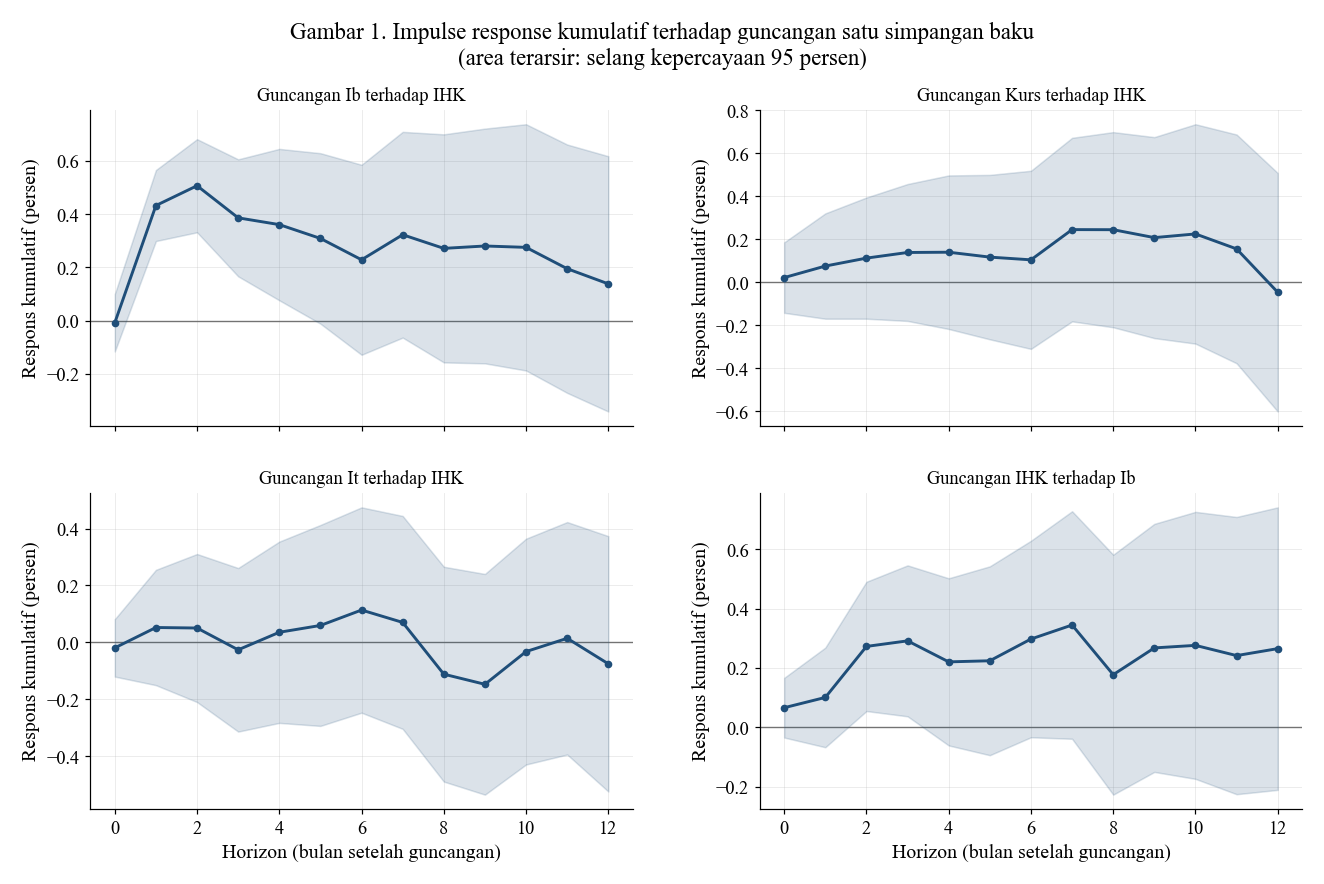

Keterangan variabel:
   Kurs   = kurs rupiah
   It     = It (harga diterima petani)
   Ib     = Ib (harga dibayar petani)
   IHK    = IHK (harga konsumen)

Sumbu tegak menyatakan akumulasi respons sejak bulan ke nol. Guncangan berukuran satu
simpangan baku, yaitu ukuran guncangan yang lazim terjadi pada data ini, bukan satu persen.


In [23]:
# Sel 8.1 - Gambar 1: impulse response sistem harga provinsi

SINGKAT = {"l_kurs": "Kurs", "l_it": "It", "l_ib": "Ib", "l_ihk": "IHK"}
PANJANG = {"l_kurs": "kurs rupiah", "l_it": "It (harga diterima petani)",
           "l_ib": "Ib (harga dibayar petani)", "l_ihk": "IHK (harga konsumen)"}

pilih = [("e_l_ib", "l_ihk"), ("e_l_kurs", "l_ihk"), ("e_l_it", "l_ihk"), ("e_l_ihk", "l_ib")]
pilih = [k for k in pilih if k in LP]
fig, sb = plt.subplots(2, 2, figsize=(11.8, 7.8), sharex=True)
sb = sb.ravel()
for ax, (g, r) in zip(sb, pilih):
    t = LP[(g, r)]
    x = t.h.values
    ax.axhline(0, color="0.45", linewidth=0.9, zorder=1)
    ax.fill_between(x, 100 * t.kum_bawah, 100 * t.kum_atas, color=PALET[0], alpha=0.16, zorder=2)
    ax.plot(x, 100 * t.kumulatif, color=PALET[0], linewidth=1.9, zorder=3)
    ax.scatter(x, 100 * t.kumulatif, s=16, color=PALET[0], zorder=4)
    ax.set_title("Guncangan " + SINGKAT[g[2:]] + " terhadap " + SINGKAT[r], fontsize=UKURAN - 1)
    ax.set_ylabel("Respons kumulatif (persen)")
    ax.set_xticks(range(0, H_MAKS + 1, 2))
for ax in sb[len(pilih) - 2:len(pilih)]:
    ax.set_xlabel("Horizon (bulan setelah guncangan)")
fig.suptitle("Gambar 1. Impulse response kumulatif terhadap guncangan satu simpangan baku\n"
             "(area terarsir: selang kepercayaan 95 persen)")
simpan_gambar(fig, "gambar_01_impulse_response",
              "Impulse response kumulatif sistem harga bulanan provinsi, metode local projection")
plt.show()
print("Keterangan variabel:")
for k, v in PANJANG.items():
    print("  ", SINGKAT[k].ljust(6), "=", v)
print()
print("Sumbu tegak menyatakan akumulasi respons sejak bulan ke nol. Guncangan berukuran satu")
print("simpangan baku, yaitu ukuran guncangan yang lazim terjadi pada data ini, bukan satu persen.")

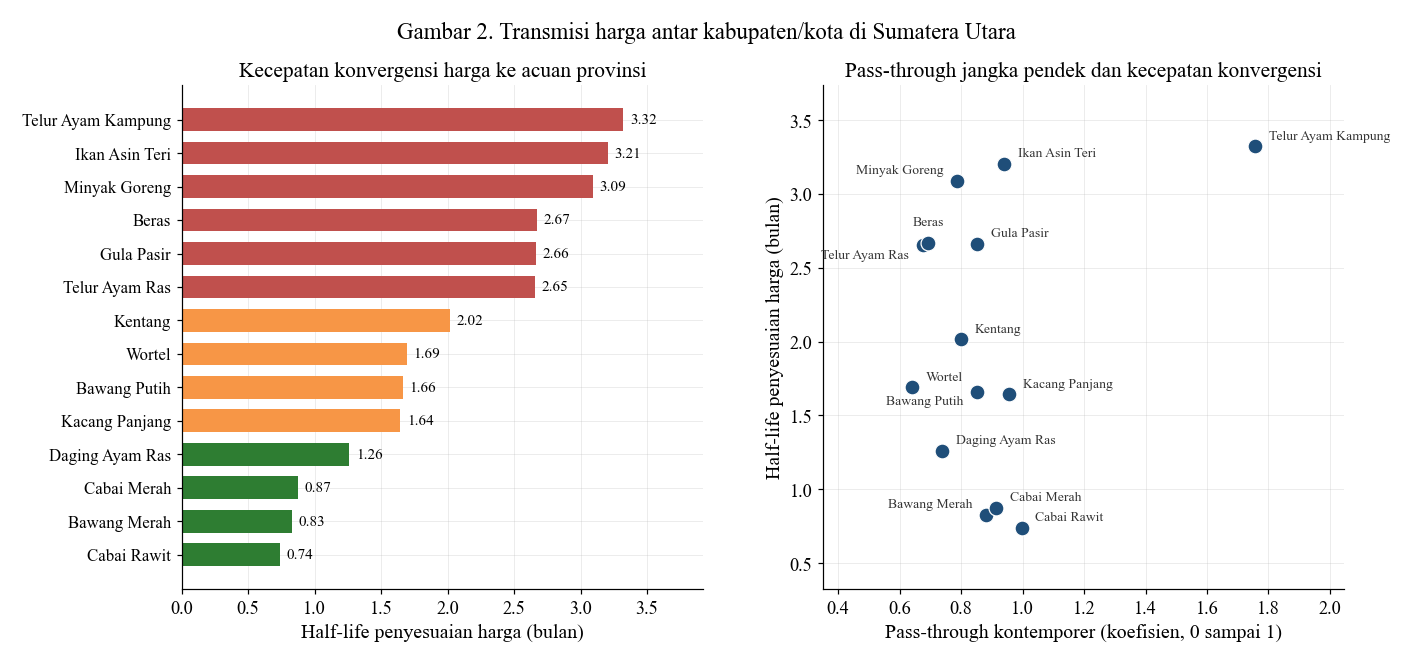

Half-life adalah jumlah bulan yang dibutuhkan untuk menutup separuh deviasi harga lokal
terhadap harga acuan provinsi. Semakin panjang, semakin lama deviasi harga bertahan.
Pass-through kontemporer adalah bagian perubahan harga acuan yang sampai ke daerah
tersebut dalam bulan yang sama. Nilai 1 berarti diteruskan penuh dan seketika.


In [24]:
# Sel 8.2 - Gambar 2: half-life dan pass-through harga menurut komoditas

rk2 = rk.reset_index().sort_values("paruh_waktu_median")
fig, sb = plt.subplots(1, 2, figsize=(12.6, 5.8))

pos = np.arange(len(rk2))
warna = np.where(rk2.paruh_waktu_median >= 2.5, PALET[1],
                 np.where(rk2.paruh_waktu_median >= 1.5, PALET[5], PALET[8]))
sb[0].barh(pos, rk2.paruh_waktu_median, color=warna, height=0.68)
sb[0].set_yticks(pos); sb[0].set_yticklabels(rk2.komoditas, fontsize=UKURAN - 2)
sb[0].set_xlabel("Half-life penyesuaian harga (bulan)")
sb[0].set_title("Kecepatan konvergensi harga ke acuan provinsi")
for p, v in zip(pos, rk2.paruh_waktu_median):
    sb[0].text(v + 0.05, p, format(v, ".2f"), va="center", fontsize=UKURAN - 3)
sb[0].set_xlim(0, float(rk2.paruh_waktu_median.max()) * 1.18)

sb[1].scatter(rk2.penerusan_median, rk2.paruh_waktu_median, s=95, color=PALET[0],
              edgecolors="white", linewidths=0.8, zorder=3)
sb[1].set_xlabel("Pass-through kontemporer (koefisien, 0 sampai 1)")
sb[1].set_ylabel("Half-life penyesuaian harga (bulan)")
sb[1].set_title("Pass-through jangka pendek dan kecepatan konvergensi")
sb[1].margins(x=0.26, y=0.16)
label_tanpa_tumpang(sb[1], rk2.penerusan_median.values, rk2.paruh_waktu_median.values,
                    rk2.komoditas.tolist(), fontsize=UKURAN - 4)

fig.suptitle("Gambar 2. Transmisi harga antar kabupaten/kota di Sumatera Utara")
simpan_gambar(fig, "gambar_02_transmisi_harga",
              "Half-life penyesuaian dan pass-through kontemporer menurut komoditas")
plt.show()
print("Half-life adalah jumlah bulan yang dibutuhkan untuk menutup separuh deviasi harga lokal")
print("terhadap harga acuan provinsi. Semakin panjang, semakin lama deviasi harga bertahan.")
print("Pass-through kontemporer adalah bagian perubahan harga acuan yang sampai ke daerah")
print("tersebut dalam bulan yang sama. Nilai 1 berarti diteruskan penuh dan seketika.")

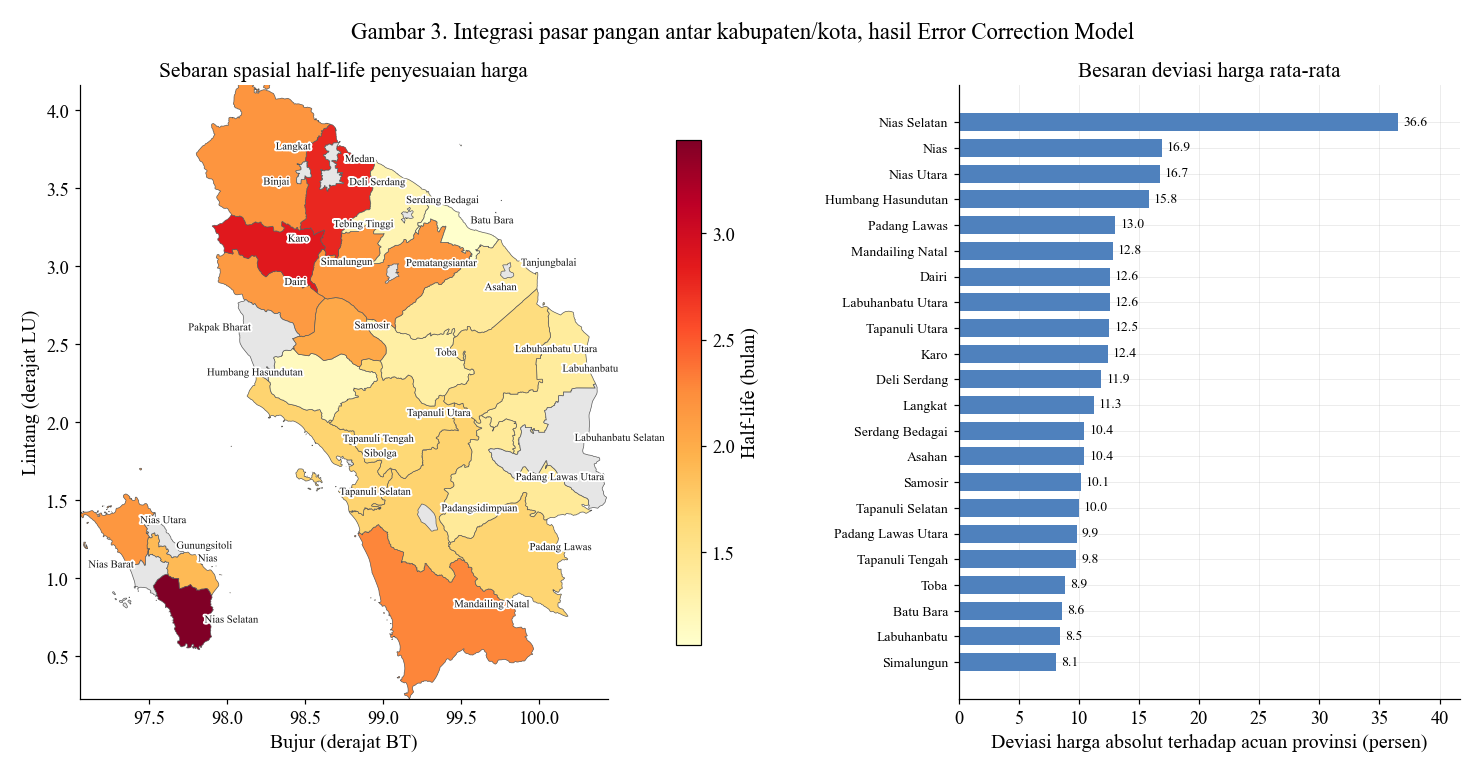

Wilayah berwarna abu-abu tidak memiliki estimasi karena cakupan komoditasnya kurang dari
lima, sehingga peringkatnya tidak dapat dibandingkan secara adil dengan wilayah lain.


In [25]:
# Sel 8.3 - Gambar 3: peta tematik integrasi pasar tingkat kabupaten/kota

peta_half = dict(zip(peringkat.kode_wilayah, peringkat.paruh_waktu_median))
fig, sb = plt.subplots(1, 2, figsize=(13.2, 6.8), gridspec_kw={"width_ratios": [1.12, 1.0]})

peta_tematik(sb[0], peta_half, cmap="YlOrRd",
             judul_skala="Half-life (bulan)", label=True, ukuran_label=UKURAN - 6)
sb[0].set_title("Sebaran spasial half-life penyesuaian harga")

pr2 = peringkat.sort_values("deviasi_mutlak_median")
pos = np.arange(len(pr2))
sb[1].barh(pos, pr2.deviasi_mutlak_median, color=PALET[2], height=0.70)
sb[1].set_yticks(pos); sb[1].set_yticklabels(pr2.wilayah, fontsize=UKURAN - 4)
sb[1].set_xlabel("Deviasi harga absolut terhadap acuan provinsi (persen)")
sb[1].set_title("Besaran deviasi harga rata-rata")
for p, v in zip(pos, pr2.deviasi_mutlak_median):
    sb[1].text(v + 0.4, p, format(v, ".1f"), va="center", fontsize=UKURAN - 4)
sb[1].set_xlim(0, float(pr2.deviasi_mutlak_median.max()) * 1.14)

fig.suptitle("Gambar 3. Integrasi pasar pangan antar kabupaten/kota, hasil Error Correction Model")
simpan_gambar(fig, "gambar_03_integrasi_pasar",
              "Peta half-life penyesuaian harga dan besaran deviasi harga menurut kabupaten/kota")
plt.show()
print("Wilayah berwarna abu-abu tidak memiliki estimasi karena cakupan komoditasnya kurang dari")
print("lima, sehingga peringkatnya tidak dapat dibandingkan secara adil dengan wilayah lain.")

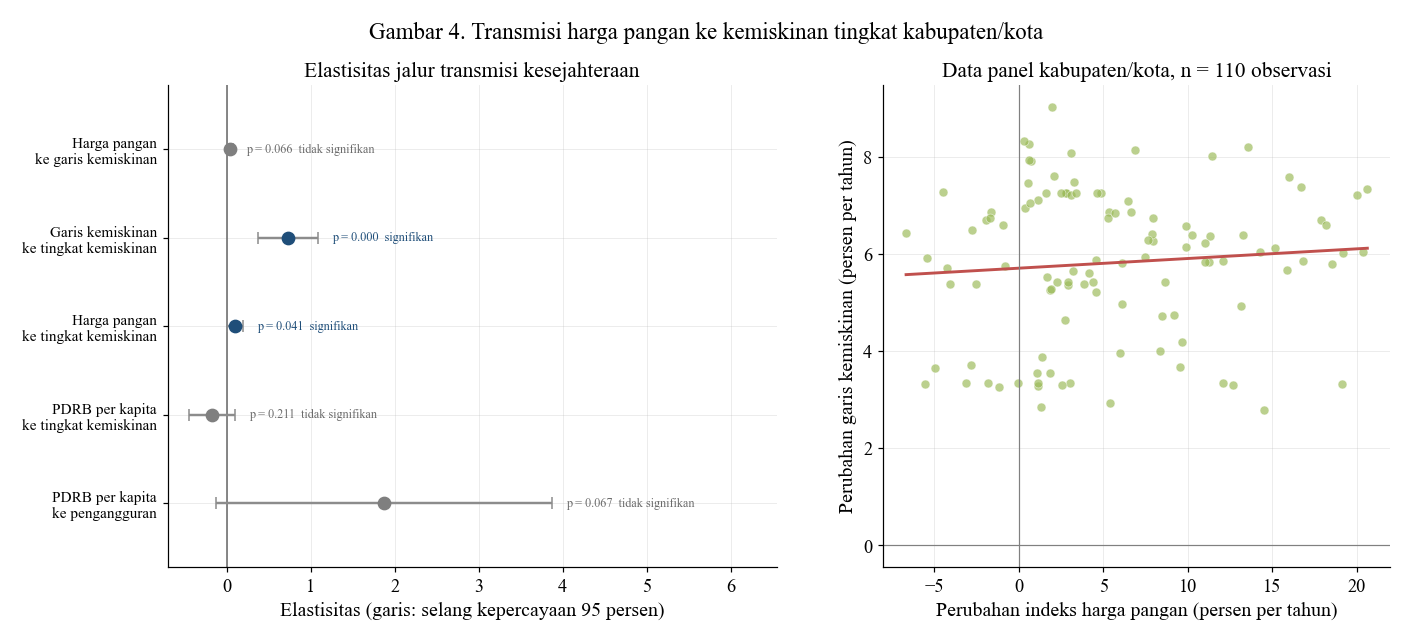

Titik biru menandai elastisitas yang signifikan pada taraf 5 persen, titik abu-abu
menandai yang tidak signifikan. Panjang garis menyatakan ketidakpastian estimasi:
garis yang melewati angka nol berarti arah pengaruhnya pun belum dapat dipastikan.


In [26]:
# Sel 8.4 - Gambar 4: elastisitas jalur transmisi harga pangan ke kemiskinan

fig, sb = plt.subplots(1, 2, figsize=(12.6, 5.6), gridspec_kw={"width_ratios": [1.20, 1.0]})

daftar = []
for m, v, lbl in [(m_gk, "d_l_ipangan", "Harga pangan\nke garis kemiskinan"),
                  (m_p0, "d_l_gk", "Garis kemiskinan\nke tingkat kemiskinan"),
                  (m_rf, "d_l_ipangan", "Harga pangan\nke tingkat kemiskinan"),
                  (m_p0, "d_l_pdrbpc", "PDRB per kapita\nke tingkat kemiskinan"),
                  (m_tpt, "d_l_pdrbpc", "PDRB per kapita\nke pengangguran")]:
    if m is not None and v in m.params:
        daftar.append({"label": lbl, "b": float(m.params[v]), "se": float(m.bse[v]),
                       "p": float(m.pvalues[v])})
E = pd.DataFrame(daftar)
pos = np.arange(len(E))[::-1]
sb[0].axvline(0, color="0.4", linewidth=1.0, zorder=1)
warna_titik = [PALET[0] if p_ < 0.05 else PALET[7] for p_ in E.p]
for bb, pp, se_, w in zip(E.b, pos, E.se, warna_titik):
    sb[0].errorbar(bb, pp, xerr=1.96 * se_, fmt="o", color=w, ecolor="0.55",
                   elinewidth=1.6, capsize=4, markersize=8, zorder=3)
sb[0].set_yticks(pos); sb[0].set_yticklabels(E.label, fontsize=UKURAN - 3)
sb[0].set_xlabel("Elastisitas (garis: selang kepercayaan 95 persen)")
sb[0].set_title("Elastisitas jalur transmisi kesejahteraan")
# Keterangan signifikansi ditaruh di ujung kanan selang agar tidak terpotong tepi gambar
kanan = (E.b + 1.96 * E.se).max()
lebar = kanan - (E.b - 1.96 * E.se).min()
for bb, pp, se_, p_ in zip(E.b, pos, E.se, E.p):
    sb[0].annotate("p = " + format(p_, ".3f") +
                   ("  signifikan" if p_ < 0.05 else "  tidak signifikan"),
                   (bb + 1.96 * se_, pp), textcoords="offset points", xytext=(9, 0),
                   ha="left", va="center", fontsize=UKURAN - 5,
                   color=(PALET[0] if p_ < 0.05 else "0.42"))
sb[0].set_xlim((E.b - 1.96 * E.se).min() - 0.06 * lebar, kanan + 0.62 * lebar)
sb[0].margins(y=0.18)

wj = KESRA.dropna(subset=["d_l_gk", "d_l_ipangan"])
sb[1].scatter(100 * wj.d_l_ipangan, 100 * wj.d_l_gk, s=34, color=PALET[3],
              alpha=0.68, edgecolors="white", linewidths=0.4)
if len(wj) > 5:
    b1, a1 = np.polyfit(wj.d_l_ipangan, wj.d_l_gk, 1)
    xs = np.linspace(wj.d_l_ipangan.min(), wj.d_l_ipangan.max(), 40)
    sb[1].plot(100 * xs, 100 * (a1 + b1 * xs), color=PALET[1], linewidth=1.9)
sb[1].axhline(0, color="0.5", linewidth=0.8); sb[1].axvline(0, color="0.5", linewidth=0.8)
sb[1].set_xlabel("Perubahan indeks harga pangan (persen per tahun)")
sb[1].set_ylabel("Perubahan garis kemiskinan (persen per tahun)")
sb[1].set_title("Data panel kabupaten/kota, n = " + str(len(wj)) + " observasi")

fig.suptitle("Gambar 4. Transmisi harga pangan ke kemiskinan tingkat kabupaten/kota")
simpan_gambar(fig, "gambar_04_transmisi_kesejahteraan",
              "Elastisitas jalur transmisi harga pangan ke kemiskinan beserta selang kepercayaan")
plt.show()
print("Titik biru menandai elastisitas yang signifikan pada taraf 5 persen, titik abu-abu")
print("menandai yang tidak signifikan. Panjang garis menyatakan ketidakpastian estimasi:")
print("garis yang melewati angka nol berarti arah pengaruhnya pun belum dapat dipastikan.")

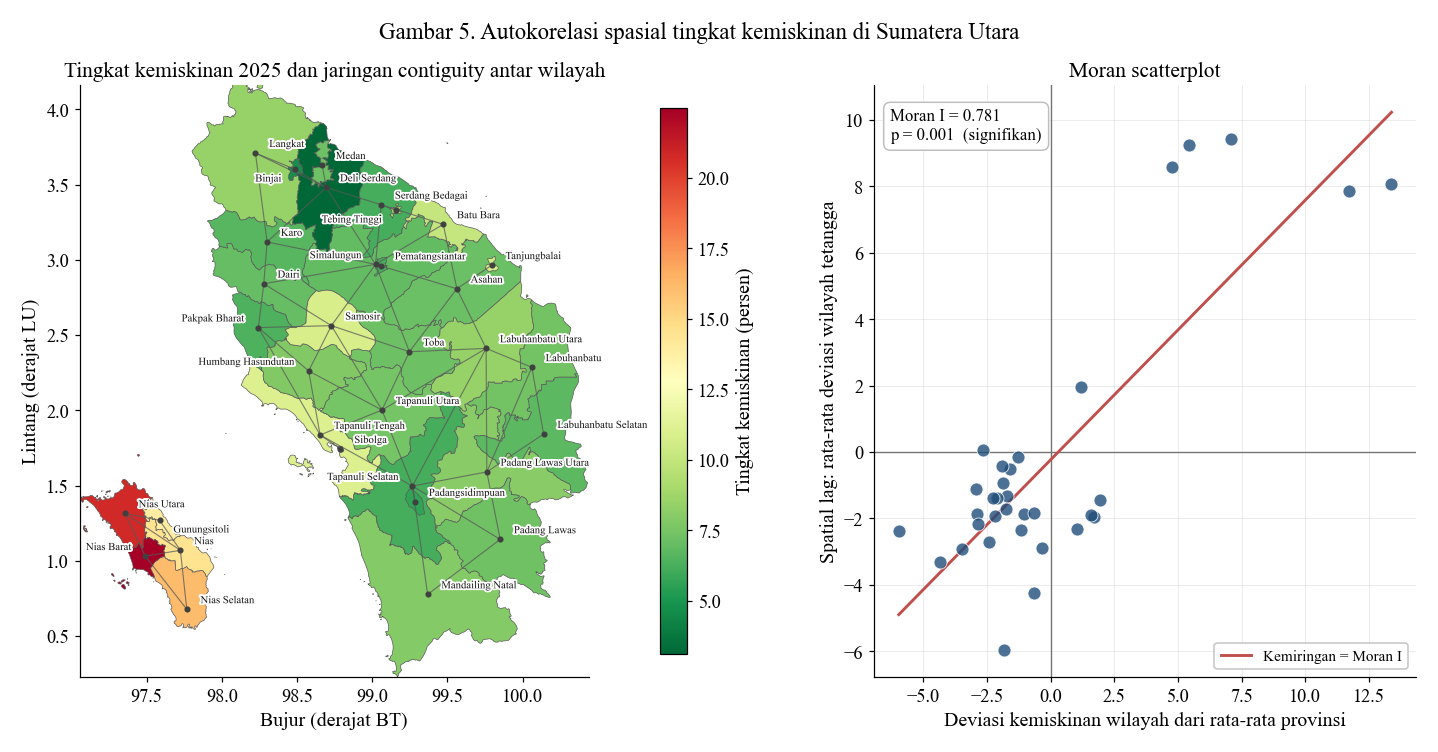

Moran scatterplot membaca pola begini. Titik pada kuadran kanan atas adalah wilayah
miskin yang dikelilingi wilayah miskin, kuadran kiri bawah adalah wilayah sejahtera
dikelilingi wilayah sejahtera. Kemiringan garis regresi persis sama dengan Moran I,
sehingga kemiringan positif berarti terbentuk klaster, bukan sebaran acak.


In [27]:
# Sel 8.5 - Gambar 5: autokorelasi spasial tingkat kemiskinan

sub_m = KAB[KAB.tahun == tahun_moran].set_index("kode_wilayah")
peta_p0 = {k: float(sub_m.loc[k, "Kemiskinan_Persentase"])
           for k in kode_urut if k in sub_m.index
           and np.isfinite(sub_m.loc[k, "Kemiskinan_Persentase"])}

fig, sb = plt.subplots(1, 2, figsize=(13.2, 6.6), gridspec_kw={"width_ratios": [1.12, 1.0]})

peta_tematik(sb[0], peta_p0, cmap="RdYlGn_r", judul_skala="Tingkat kemiskinan (persen)",
             garis_tetangga=KONTIGU, label=True, ukuran_label=UKURAN - 6)
sb[0].set_title("Tingkat kemiskinan " + str(tahun_moran) +
                " dan jaringan contiguity antar wilayah")

nilai = np.array([peta_p0.get(k, np.nan) for k in kode_urut], dtype=float)
z = nilai - np.nanmean(nilai)
Wz = W_KONTIGU @ np.nan_to_num(z)
sah = np.isfinite(z)
sb[1].axhline(0, color="0.45", linewidth=0.9); sb[1].axvline(0, color="0.45", linewidth=0.9)
sb[1].scatter(z[sah], Wz[sah], s=72, color=PALET[0], alpha=0.80,
              edgecolors="white", linewidths=0.6, zorder=3)
if sah.sum() > 5:
    bb = np.polyfit(z[sah], Wz[sah], 1)
    xs = np.linspace(np.nanmin(z), np.nanmax(z), 30)
    sb[1].plot(xs, bb[1] + bb[0] * xs, color=PALET[1], linewidth=1.9,
               label="Kemiringan = Moran I")
    sb[1].legend(loc="lower right", fontsize=UKURAN - 3)
mi = MORAN[(MORAN.variabel == "Kemiskinan_Persentase") &
           (MORAN.pembobot.str.startswith("Contiguity"))]
if len(mi):
    p_mi = float(mi.p_permutasi.iloc[0])
    sb[1].text(0.03, 0.96, "Moran I = " + format(float(mi.I.iloc[0]), ".3f") +
               "\np = " + format(p_mi, ".3f") +
               ("  (signifikan)" if p_mi < 0.05 else "  (tidak signifikan)"),
               transform=sb[1].transAxes, va="top", fontsize=UKURAN - 2,
               bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="0.75"))
sb[1].set_xlabel("Deviasi kemiskinan wilayah dari rata-rata provinsi")
sb[1].set_ylabel("Spatial lag: rata-rata deviasi wilayah tetangga")
sb[1].set_title("Moran scatterplot")

fig.suptitle("Gambar 5. Autokorelasi spasial tingkat kemiskinan di Sumatera Utara")
simpan_gambar(fig, "gambar_05_autokorelasi_spasial_kemiskinan",
              "Peta kemiskinan dengan jaringan contiguity dan Moran scatterplot")
plt.show()
print("Moran scatterplot membaca pola begini. Titik pada kuadran kanan atas adalah wilayah")
print("miskin yang dikelilingi wilayah miskin, kuadran kiri bawah adalah wilayah sejahtera")
print("dikelilingi wilayah sejahtera. Kemiringan garis regresi persis sama dengan Moran I,")
print("sehingga kemiringan positif berarti terbentuk klaster, bukan sebaran acak.")

---
## Bagian 9. Tabel parameter untuk notebook 03

Seluruh parameter yang diestimasi sepanjang notebook ini dikumpulkan menjadi satu tabel. Tiap baris memuat
nilai, galat baku, nilai p, jumlah observasi, dan penilaian presisi. Penilaian presisi memakai kaidah
tetap: presisi tinggi bila nilai mutlak koefisien mencapai 2,58 kali galat bakunya, yaitu signifikan pada
taraf 1 persen; sedang bila mencapai 1,96 kali, yaitu signifikan pada taraf 5 persen; dan rendah bila di
bawah itu.

Notebook 03 diwajibkan memperlakukan ketiganya secara berbeda. Parameter berpresisi tinggi dipakai dengan
nilai titiknya. Parameter berpresisi sedang dipakai dengan nilai titiknya namun disertai analisis
sensitivitas pada selang kepercayaannya. Parameter berpresisi rendah tidak boleh dipakai sebagai nilai
titik sama sekali. Untuk parameter jenis ini, notebook 03 harus menjalankan simulasi pada beberapa nilai
di sepanjang selang yang masuk akal, lalu melaporkan apakah kesimpulan kebijakan berubah. Bila berubah,
maka kesimpulan itu memang tidak dapat ditarik dari data yang tersedia dan harus dinyatakan demikian.

In [28]:
# Sel 9.1 - Perakitan tabel parameter

TABEL_PARAMETER = pd.DataFrame(PARAMETER)
TABEL_PARAMETER["nilai"] = pd.to_numeric(TABEL_PARAMETER.nilai, errors="coerce")
TABEL_PARAMETER["galat_baku"] = pd.to_numeric(TABEL_PARAMETER.galat_baku, errors="coerce")
TABEL_PARAMETER["batas_bawah_95"] = TABEL_PARAMETER.nilai - 1.96 * TABEL_PARAMETER.galat_baku
TABEL_PARAMETER["batas_atas_95"] = TABEL_PARAMETER.nilai + 1.96 * TABEL_PARAMETER.galat_baku
TABEL_PARAMETER["signifikan_5persen"] = np.where(
    TABEL_PARAMETER.nilai_p.notna(),
    np.where(TABEL_PARAMETER.nilai_p < 0.05, "ya", "tidak"), "tidak diuji")
TABEL_PARAMETER["perlakuan_nb03"] = TABEL_PARAMETER.presisi.map({
    "tinggi": "Pakai nilai titik",
    "sedang": "Pakai nilai titik, uji sensitivitas pada selang",
    "rendah": "Jangan pakai nilai titik, telusuri sepanjang selang",
    "tidak diketahui": "Perlakukan sebagai perkiraan awal, wajib ditelusuri"})
TABEL_PARAMETER = TABEL_PARAMETER.sort_values(["blok", "parameter"]).reset_index(drop=True)
simpan(TABEL_PARAMETER, "tabel/parameter_untuk_notebook03.csv")

print("TABEL PARAMETER")
print("Total parameter tercatat:", len(TABEL_PARAMETER))
print()
print("Sebaran menurut blok dan presisi:")
print(pd.crosstab(TABEL_PARAMETER.blok, TABEL_PARAMETER.presisi,
                  margins=True, margins_name="Jumlah").to_string())
print()
print("Parameter berpresisi tinggi, yaitu yang siap dipakai langsung:")
tinggi = TABEL_PARAMETER[TABEL_PARAMETER.presisi == "tinggi"]
if len(tinggi):
    print(tinggi[["blok", "parameter", "nilai", "galat_baku", "nilai_p", "n_amatan", "satuan"]]
          .round(4).to_string(index=False))
else:
    print("  tidak ada")
print()
print("Parameter berpresisi rendah, yang wajib ditelusuri sepanjang selang di notebook 03:")
rendah = TABEL_PARAMETER[TABEL_PARAMETER.presisi.isin(["rendah", "tidak diketahui"])]
print("  jumlah:", len(rendah))
if len(rendah):
    print(rendah[["blok", "parameter", "nilai", "batas_bawah_95", "batas_atas_95"]]
          .head(18).round(4).to_string(index=False))

TABEL PARAMETER
Total parameter tercatat: 96

Sebaran menurut blok dan presisi:
presisi                   rendah  sedang  tinggi  Jumlah
blok                                                    
A. Sistem harga provinsi      14       1       1      16
B. Transmisi harga             0       4      24      28
C. Respons penawaran           4       1       0       5
D. Rantai kesejahteraan        5       1       1       7
E. Spasial                    22       5      13      40
Jumlah                        45      12      39      96

Parameter berpresisi tinggi, yaitu yang siap dipakai langsung:
                    blok                                                             parameter  nilai  galat_baku  nilai_p  n_amatan                                satuan
A. Sistem harga provinsi                      Respons l_ihk thd guncangan l_ib pada bulan ke 3 0.3864      0.1122   0.0758        66 persen per guncangan 1 simpangan baku
      B. Transmisi harga                              Half

In [29]:
# Sel 9.2 - Berkas ringkas parameter inti untuk kalibrasi

INTI_NB03 = []

def tarik(pola, blok=None):
    s = TABEL_PARAMETER
    if blok:
        s = s[s.blok == blok]
    return s[s.parameter.str.contains(pola, case=False, regex=True, na=False)]

for kunci, pola, blok, peran in [
    ("elastisitas_gk_thd_harga_pangan", "garis kemiskinan thd harga pangan", "D. Rantai kesejahteraan",
     "Menghubungkan harga pangan ke garis kemiskinan"),
    ("elastisitas_kemiskinan_thd_gk", "kemiskinan thd garis kemiskinan", "D. Rantai kesejahteraan",
     "Menghubungkan garis kemiskinan ke jumlah penduduk miskin"),
    ("elastisitas_kemiskinan_thd_harga_pangan", "kemiskinan thd harga pangan .bentuk ringkas",
     "D. Rantai kesejahteraan", "Jalur ringkas untuk pemeriksaan silang"),
    ("elastisitas_kemiskinan_thd_pdrb", "kemiskinan thd PDRB", "D. Rantai kesejahteraan",
     "Jalur pertumbuhan menuju pengurangan kemiskinan"),
    ("elastisitas_pengangguran_thd_pdrb", "pengangguran thd PDRB", "D. Rantai kesejahteraan",
     "Bentuk Okun tingkat daerah"),
    ("elastisitas_penawaran_hortikultura", "luas panen hortikultura", "C. Respons penawaran",
     "Balancing loop (B) harga menuju luas tanam"),
]:
    s = tarik(pola, blok)
    if len(s):
        r = s.iloc[0]
        INTI_NB03.append({"kunci": kunci, "nilai": r["nilai"], "galat_baku": r["galat_baku"],
                          "batas_bawah_95": r["batas_bawah_95"], "batas_atas_95": r["batas_atas_95"],
                          "presisi": r["presisi"], "peran_dalam_model": peran,
                          "sumber_parameter": r["parameter"]})

for _, r in rk.reset_index().iterrows():
    kom = re.sub(r"[^a-z0-9]+", "_", r["komoditas"].lower()).strip("_")
    INTI_NB03.append({"kunci": "half_life_harga_" + kom,
                      "nilai": float(r["paruh_waktu_median"]), "galat_baku": np.nan,
                      "batas_bawah_95": np.nan, "batas_atas_95": np.nan,
                      "presisi": "tinggi" if r["n_wilayah"] >= 15 else "sedang",
                      "peran_dalam_model": "Kecepatan konvergensi harga antar kabupaten/kota",
                      "sumber_parameter": "Median Error Correction Model, " +
                                          str(int(r["n_wilayah"])) + " wilayah"})
    INTI_NB03.append({"kunci": "pass_through_harga_" + kom,
                      "nilai": float(r["penerusan_median"]), "galat_baku": np.nan,
                      "batas_bawah_95": np.nan, "batas_atas_95": np.nan,
                      "presisi": "tinggi" if r["n_wilayah"] >= 15 else "sedang",
                      "peran_dalam_model": "Bagian guncangan harga yang diteruskan dalam bulan sama",
                      "sumber_parameter": "Median Error Correction Model, " +
                                          str(int(r["n_wilayah"])) + " wilayah"})

for (g, r_), t in LP.items():
    if r_ == "l_ihk" and 3 < len(t):
        INTI_NB03.append({"kunci": "impulse_response_ihk_thd_" + g[2:] + "_3bulan",
                          "nilai": float(100 * t.iloc[3].kumulatif),
                          "galat_baku": float(100 * t.iloc[3].kum_se),
                          "batas_bawah_95": float(100 * t.iloc[3].kum_bawah),
                          "batas_atas_95": float(100 * t.iloc[3].kum_atas),
                          "presisi": "tinggi" if abs(t.iloc[3].kumulatif) > 2.58 * t.iloc[3].kum_se
                                     else ("sedang" if abs(t.iloc[3].kumulatif) > 1.96 * t.iloc[3].kum_se
                                           else "rendah"),
                          "peran_dalam_model": "Penjalaran guncangan ke inflasi konsumen",
                          "sumber_parameter": "Local projection, horizon 3 bulan"})

PARAMETER_INTI = pd.DataFrame(INTI_NB03)
simpan(PARAMETER_INTI, "tabel/parameter_inti_kalibrasi.csv")

jalur_json = DIR_KELUARAN / "tabel" / "parameter_inti_kalibrasi.json"
PARAMETER_INTI.to_json(jalur_json, orient="records", indent=1)
if DIR_DRIVE is not None:
    PARAMETER_INTI.to_json(DIR_DRIVE / "tabel" / "parameter_inti_kalibrasi.json",
                           orient="records", indent=1)

print("PARAMETER INTI UNTUK KALIBRASI NOTEBOOK 03")
print("Jumlah:", len(PARAMETER_INTI))
print()
print(PARAMETER_INTI[["kunci", "nilai", "batas_bawah_95", "batas_atas_95", "presisi"]]
      .round(4).to_string(index=False))
print()
print("Disimpan juga dalam bentuk JSON agar dapat dibaca langsung oleh notebook 03")
print("dan oleh dashboard di notebook 04:", jalur_json.name)

PARAMETER INTI UNTUK KALIBRASI NOTEBOOK 03
Jumlah: 37

                                  kunci   nilai  batas_bawah_95  batas_atas_95 presisi
        elastisitas_gk_thd_harga_pangan  0.0331         -0.0022         0.0684  rendah
          elastisitas_kemiskinan_thd_gk  0.7280          0.3716         1.0843  tinggi
elastisitas_kemiskinan_thd_harga_pangan  0.0990          0.0039         0.1941  sedang
        elastisitas_kemiskinan_thd_pdrb -0.1736         -0.4460         0.0987  rendah
      elastisitas_pengangguran_thd_pdrb  1.8709         -0.1283         3.8701  rendah
     elastisitas_penawaran_hortikultura  0.0353         -0.4343         0.5050  rendah
     half_life_harga_telur_ayam_kampung  3.3220             NaN            NaN  sedang
  pass_through_harga_telur_ayam_kampung  1.7570             NaN            NaN  sedang
         half_life_harga_ikan_asin_teri  3.2060             NaN            NaN  sedang
      pass_through_harga_ikan_asin_teri  0.9390             NaN            

---
## Bagian 10. Interpretasi otomatis

Ringkasan berikut disusun dengan kaidah yang sama seperti notebook 01. Kerangka kalimat tetap, diisi
nilai yang benar benar terhitung. Bila suatu estimasi tidak signifikan pada taraf 5 persen, kalimatnya
menyatakan hal itu secara langsung, bukan menutupinya dengan pilihan kata yang mengesankan hasil positif.

In [30]:
# Sel 10.1 - Ringkasan naratif berbasis nilai terhitung

BARIS = []
def tulis(t):
    if t:
        BARIS.append(t)

def ang(x, d=3):
    if x is None or not np.isfinite(float(x)):
        return "tidak tersedia"
    return format(round(float(x), d), "." + str(d) + "f")

def sig(p):
    return "signifikan pada taraf 5 persen" if p < 0.05 else "tidak signifikan pada taraf 5 persen"

tulis("GEOMETRI DAN STRUKTUR SPASIAL")
tulis("Analisis keruangan memakai batas administrasi resmi kabupaten dan kota, sebanyak " +
      str(len(GEOM)) + " poligon dengan total " +
      format(sum(len(r) for k in kode_urut for r in GEOM[k]['ring']), ",") + " vertex batas.")
tulis("Pemasangan geometri ke data statistik dilakukan berdasarkan nama wilayah, sebab " +
      str(len(beda)) + " dari " + str(int(PADAN.kode_bps.notna().sum())) + " wilayah memiliki kode " +
      "Kementerian Dalam Negeri yang berbeda dari kode Badan Pusat Statistik. Memakai kode " +
      "secara langsung akan menukar poligon antar wilayah tanpa memberi tanda apa pun.")
tulis("Total luas hasil perhitungan poligon sebesar " + format(int(sum(LUAS_KM2.values())), ",") +
      " kilometer persegi, sejalan dengan luas daratan Sumatera Utara yang tercatat pada " +
      "publikasi resmi, sehingga geometri yang dipakai dapat dianggap benar.")
tulis("Ketetanggaan contiguity menghasilkan rata-rata " +
      ang(float(KONTIGU.sum(axis=1).mean()), 2) + " tetangga per wilayah. Graf terbagi menjadi " +
      str(len(komponen)) + " komponen terhubung, dengan gugus Kepulauan Nias terpisah dari daratan.")
mg = MORAN[MORAN.pembobot.str.startswith("Contiguity")]
n_sig_g = int((mg.p_permutasi < 0.05).sum())
tulis("Uji Moran I dengan pembobot contiguity menunjukkan " + str(n_sig_g) + " dari " + str(len(mg)) +
      " indikator membentuk klaster spasial yang signifikan pada taraf 5 persen.")
if len(mg):
    ter = mg.loc[mg.I.idxmax()]
    tulis("Klaster terkuat terdapat pada " + str(ter["variabel"]) + " dengan Moran I sebesar " +
          ang(ter["I"]) + " dan nilai p " + ang(ter["p_permutasi"]) + ", yang berarti kabupaten " +
          "yang berbatasan cenderung memiliki nilai serupa.")

tulis("")
tulis("SISTEM HARGA TINGKAT PROVINSI")
tulis("Sistem diestimasi pada " + str(len(D_SIS)) + " bulan dengan panjang lag " + str(P_LAG) +
      ". Uji jejak Johansen memberi rank kointegrasi " +
      ("yang tegas sebesar " + str(rank_terpilih) if tegas else
       "yang berubah menurut panjang lag, sehingga spesifikasi utama memakai pembedaan pertama") + ".")
kunci_ib = ("e_l_ib", "l_ihk")
if kunci_ib in LP and 3 < len(LP[kunci_ib]):
    x = LP[kunci_ib].iloc[3]
    signifikan = (x.kum_bawah > 0) or (x.kum_atas < 0)
    tulis("Guncangan sebesar satu simpangan baku pada Ib, yaitu indeks harga yang dibayar petani, " +
          "menggerakkan IHK sebesar " + ang(100 * x.kumulatif, 2) +
          " persen secara kumulatif dalam tiga bulan, dengan selang kepercayaan 95 persen dari " +
          ang(100 * x.kum_bawah, 2) + " sampai " + ang(100 * x.kum_atas, 2) + " persen. Selang ini " +
          ("tidak melewati nol, sehingga pengaruhnya signifikan pada taraf 5 persen."
           if signifikan else "melewati nol, sehingga pengaruhnya tidak signifikan pada taraf 5 persen."))
    if signifikan:
        tulis("Temuan ini masuk akal secara ekonomi. Ib sebagian besar berisi konsumsi rumah " +
              "tangga perdesaan, sehingga keranjangnya beririsan luas dengan keranjang IHK. " +
              "Keduanya digerakkan oleh harga pangan yang sama.")
kunci_k = ("e_l_kurs", "l_ihk")
if kunci_k in LP and 6 < len(LP[kunci_k]):
    x = LP[kunci_k].iloc[6]
    signifikan = (x.kum_bawah > 0) or (x.kum_atas < 0)
    tulis("Exchange rate pass-through ke IHK dalam enam bulan sebesar " + ang(100 * x.kumulatif, 2) +
          " persen dan " + ("signifikan" if signifikan else "tidak signifikan") +
          " pada taraf 5 persen, sehingga jalur nilai tukar bukan penggerak utama inflasi " +
          "Sumatera Utara pada periode ini.")
if len(KETAHANAN):
    tulis("Uji ketahanan terhadap urutan identifikasi Cholesky menunjukkan selisih terbesar " +
          ang(KETAHANAN.selisih.abs().max(), 3) + " poin persen antar urutan yang diuji.")

tulis("")
tulis("INTEGRASI PASAR ANTAR KABUPATEN DAN KOTA")
tulis("Error Correction Model berhasil diestimasi pada " + str(len(ECM)) + " pasangan wilayah kali " +
      "komoditas, dan " + ang(100 * ECM.theta_sah.mean(), 1) + " persen di antaranya menghasilkan " +
      "koefisien penyesuaian bertanda negatif dan signifikan, sebagaimana diharapkan teori.")
if len(rk):
    tercepat = rk.index[-1]; terlambat = rk.index[0]
    tulis("Komoditas dengan konvergensi tercepat adalah " + str(tercepat) + " dengan half-life " +
          ang(rk.paruh_waktu_median.iloc[-1], 2) + " bulan, sedangkan yang paling lambat adalah " +
          str(terlambat) + " dengan half-life " + ang(rk.paruh_waktu_median.iloc[0], 2) + " bulan.")
    tulis("Pola ini mengandung pesan kebijakan yang jelas. Komoditas bergejolak seperti cabai dan " +
          "bawang justru berkonvergensi paling cepat, sebab sifatnya yang mudah rusak memaksa " +
          "pedagang memindahkannya segera. Sebaliknya bahan pokok tahan simpan seperti beras, gula, " +
          "dan minyak goreng menyesuaikan jauh lebih lambat, karena penyimpanan memungkinkan " +
          "deviasi harga dibiarkan bertahan. Intervensi distribusi karena itu lebih tepat diarahkan " +
          "pada kelompok kedua, bukan pada komoditas bergejolak yang selama ini paling sering disorot.")
if len(peringkat) >= 4:
    lam = peringkat.iloc[0]; cep = peringkat.iloc[-1]
    tulis("Antar wilayah, konvergensi paling lambat terjadi di " + str(lam["wilayah"]) +
          " dengan half-life " + ang(lam["paruh_waktu_median"], 2) + " bulan dan deviasi harga " +
          "rata-rata " + ang(lam["deviasi_mutlak_median"], 1) + " persen terhadap acuan provinsi, " +
          "sedangkan tercepat di " + str(cep["wilayah"]) + " dengan half-life " +
          ang(cep["paruh_waktu_median"], 2) + " bulan.")
    tulis("Rasio antara keduanya " + ang(lam["paruh_waktu_median"] / cep["paruh_waktu_median"], 2) +
          " kali lipat. Hasil ketetanggaan contiguity memperkuat dugaan bahwa keterpencilan " +
          "berperan, sebab gugus Kepulauan Nias memang membentuk komponen graf yang terpisah dari " +
          "daratan. Pengujian formal atas dugaan itu tetap memerlukan data biaya angkut yang belum " +
          "tersedia dalam basis data ini.")

tulis("")
tulis("RESPONS PENAWARAN PETANI")
if m_gab is not None:
    b, se, p = float(m_gab.params["d_l_harga_1"]), float(m_gab.bse["d_l_harga_1"]), float(m_gab.pvalues["d_l_harga_1"])
    tulis("Elastisitas luas panen hortikultura terhadap harga tahun sebelumnya diestimasi " +
          ang(b) + " dengan galat baku " + ang(se) + " dan nilai p " + ang(p, 4) + ", sehingga " +
          sig(p) + ".")
    if p < 0.05:
        tulis("Karena signifikan, feedback loop dari harga menuju luas tanam dapat dipakai " +
              "sebagai mekanisme penyeimbang dalam model.")
    else:
        tulis("Karena tidak signifikan, angka ini tidak boleh dipakai sebagai nilai titik. Dengan " +
              "hanya empat sampai lima tahun efektif setelah pembedaan dan lag, data yang ada " +
              "memang belum sanggup mendeteksi respons tersebut. Yang tidak boleh disimpulkan " +
              "adalah bahwa petani tidak merespons harga, sebab ketiadaan bukti bukan bukti " +
              "ketiadaan. Notebook 03 menelusuri parameter ini sepanjang selang yang masuk akal.")

tulis("")
tulis("TRANSMISI HARGA PANGAN KE KEMISKINAN")
if None not in (e1, e2, e3):
    tulis("Kenaikan satu persen indeks harga pangan kabupaten berkaitan dengan kenaikan " +
          ang(e1, 4) + " persen pada garis kemiskinan, dengan nilai p " + ang(p1, 4) + " sehingga " +
          sig(p1) + ".")
    tulis("Kenaikan satu persen garis kemiskinan berkaitan dengan kenaikan " + ang(e2, 3) +
          " persen pada tingkat kemiskinan, dengan nilai p " + ang(p2, 4) + " sehingga " + sig(p2) +
          ". Inilah mata rantai yang paling presisi dalam seluruh notebook ini, dan besarnya " +
          "mencerminkan banyaknya penduduk Sumatera Utara yang hidup tepat di sekitar garis " +
          "kemiskinan.")
    sisa_rf = e3 - e1 * e2
    se_tl_r = abs(e1 * e2) * np.sqrt((se1 / e1) ** 2 + (se2 / e2) ** 2)
    sisa_signifikan = abs(sisa_rf) > 1.96 * np.sqrt(se3 ** 2 + se_tl_r ** 2)
    tulis("Bentuk ringkas memberi " + ang(e3, 4) + " persen dengan nilai p " + ang(p3, 4) +
          " sehingga " + sig(p3) + ", dibandingkan hasil kali kedua tahap yang sebesar " +
          ang(e1 * e2, 4) + " persen.")
    if sisa_signifikan:
        tulis("Selisih keduanya sebesar " + ang(sisa_rf, 4) + " persen dan berbeda signifikan dari " +
              "nol, yang menunjukkan adanya jalur tambahan di luar pergeseran garis kemiskinan, " +
              "yaitu penggerusan pendapatan riil rumah tangga.")
    else:
        tulis("Selisih keduanya sebesar " + ang(sisa_rf, 4) + " persen namun TIDAK berbeda " +
              "signifikan dari nol pada taraf 5 persen. Dengan kata lain, data yang ada belum " +
              "sanggup memastikan apakah terdapat jalur tambahan di luar pergeseran garis " +
              "kemiskinan. Notebook 03 memodelkan kedua jalur secara terpisah namun menguji " +
              "apakah kesimpulan kebijakan berubah bila jalur tambahan itu ditiadakan.")
    tulis("Terjemahan praktisnya. Bila harga pangan naik sepuluh persen dan tidak ada penyeimbang " +
          "apa pun, tingkat kemiskinan kabupaten akan naik sekitar " + ang(10 * e3, 2) +
          " persen relatif terhadap posisinya semula.")

tulis("")
tulis("LIMPAHAN ANTAR WILAYAH")
n_sah = int(SPASIAL.sah.sum())
n_pakai = int((SPASIAL.sah & SPASIAL.instrumen_kuat & (SPASIAL.p_rho < 0.05)).sum())
tulis("Dari " + str(len(SPASIAL)) + " kombinasi indikator dan pembobot, " + str(n_sah) +
      " menghasilkan koefisien spatial lag yang berada dalam rentang stabil, dan " +
      str(n_pakai) + " di antaranya sekaligus signifikan dengan instrumen kuat.")
if n_pakai == 0:
    tulis("Kesimpulannya, dengan tiga puluh tiga wilayah dan sembilan tahun, pengaruh penularan " +
          "antar tetangga tidak dapat dipisahkan secara meyakinkan dari perbedaan tetap antar " +
          "daerah dan dari guncangan yang menimpa semua daerah bersamaan. Uji Moran I tetap " +
          "menunjukkan klaster itu ada, tetapi mekanismenya tidak teridentifikasi di sini.")
    tulis("Karena itu keterkaitan antar wilayah dalam model dinamika sistem dibangun lewat jalur " +
          "harga dari Blok B, yang terestimasi jauh lebih presisi, bukan lewat koefisien spatial " +
          "lag yang tidak meyakinkan.")

tulis("")
tulis("KESIAPAN PARAMETER UNTUK NOTEBOOK 03")
n_t = int((TABEL_PARAMETER.presisi == "tinggi").sum())
n_s = int((TABEL_PARAMETER.presisi == "sedang").sum())
n_r = int(TABEL_PARAMETER.presisi.isin(["rendah", "tidak diketahui"]).sum())
tulis("Dari " + str(len(TABEL_PARAMETER)) + " parameter yang diestimasi, " + str(n_t) +
      " berpresisi tinggi, " + str(n_s) + " berpresisi sedang, dan " + str(n_r) +
      " berpresisi rendah atau tidak terukur.")
tulis("Model dinamika sistem di notebook 03 karena itu tidak boleh disajikan sebagai satu lintasan " +
      "tunggal. Yang layak disajikan adalah sebaran lintasan yang mencerminkan ketidakpastian " +
      "parameter, sehingga pembaca dapat melihat mana kesimpulan yang kokoh dan mana yang " +
      "bergantung pada asumsi.")

RINGKASAN = "\n".join(BARIS)
print(RINGKASAN)
with open(DIR_KELUARAN / "log" / "ringkasan_otomatis_nb02.txt", "w", encoding="utf-8") as f:
    f.write(RINGKASAN)
if DIR_DRIVE is not None:
    with open(DIR_DRIVE / "log" / "ringkasan_otomatis_nb02.txt", "w", encoding="utf-8") as f:
        f.write(RINGKASAN)

GEOMETRI DAN STRUKTUR SPASIAL
Analisis keruangan memakai batas administrasi resmi kabupaten dan kota, sebanyak 33 poligon dengan total 319,984 vertex batas.
Pemasangan geometri ke data statistik dilakukan berdasarkan nama wilayah, sebab 20 dari 33 wilayah memiliki kode Kementerian Dalam Negeri yang berbeda dari kode Badan Pusat Statistik. Memakai kode secara langsung akan menukar poligon antar wilayah tanpa memberi tanda apa pun.
Total luas hasil perhitungan poligon sebesar 72,802 kilometer persegi, sejalan dengan luas daratan Sumatera Utara yang tercatat pada publikasi resmi, sehingga geometri yang dipakai dapat dianggap benar.
Ketetanggaan contiguity menghasilkan rata-rata 3.58 tetangga per wilayah. Graf terbagi menjadi 2 komponen terhubung, dengan gugus Kepulauan Nias terpisah dari daratan.
Uji Moran I dengan pembobot contiguity menunjukkan 4 dari 8 indikator membentuk klaster spasial yang signifikan pada taraf 5 persen.
Klaster terkuat terdapat pada Kemiskinan_Persentase dengan Mor

In [31]:
# Sel 10.2 - Manifes dan ringkasan eksekusi

manifes = []
for p in sorted(DIR_KELUARAN.rglob("*")):
    if p.is_file() and p.suffix in [".csv", ".png", ".json", ".txt"]:
        n = None
        if p.suffix == ".csv":
            try:
                n = sum(1 for _ in open(p, encoding="utf-8")) - 1
            except Exception:
                n = None
        manifes.append({"berkas": str(p.relative_to(DIR_KELUARAN)),
                        "ukuran_kb": round(p.stat().st_size / 1024, 1), "n_baris": n})
MANIFES = pd.DataFrame(manifes)
MANIFES.to_csv(DIR_KELUARAN / "log" / "manifes_keluaran_nb02.csv", index=False)
if DIR_DRIVE is not None:
    MANIFES.to_csv(DIR_DRIVE / "log" / "manifes_keluaran_nb02.csv", index=False)

print("=" * 78)
print("NOTEBOOK 02 SELESAI")
print("=" * 78)
print("Waktu selesai   :", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Folder keluaran :", DIR_KELUARAN)
print("Salinan Drive   :", DIR_DRIVE if DIR_DRIVE else "tidak dibuat")
print("Berkas batas    :", BERKAS_BATAS.name if BERKAS_BATAS else "tidak dipakai")
print()
print(MANIFES.to_string(index=False))
print()
print("Gambar dihasilkan:", len(KATALOG_GAMBAR))
for g in KATALOG_GAMBAR:
    print("  ", g["berkas"].ljust(44), g["keterangan"])
print()
print("Langkah berikutnya: Notebook 03 membaca parameter_inti_kalibrasi.json dan geometri_wilayah.csv")
print("dari folder di atas, menyusun struktur stok dan aliran, lalu mengujinya dengan rangkaian")
print("uji validasi Barlas.")

NOTEBOOK 02 SELESAI
Waktu selesai   : 2026-08-30 22:11:39
Folder keluaran : /Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut_NB02
Salinan Drive   : /Users/user/Library/CloudStorage/GoogleDrive-dgiveup719@gmail.com/My Drive/Sumatranomics_2026_Sumut/Notebook02_20260830
Berkas batas    : batas_kabupaten_kota_sumatera_utara.geojson

                                              berkas  ukuran_kb  n_baris
               gambar/gambar_01_impulse_response.png      500.4      NaN
                gambar/gambar_02_transmisi_harga.png      366.1      NaN
                gambar/gambar_03_integrasi_pasar.png      733.0      NaN
        gambar/gambar_04_transmisi_kesejahteraan.png      332.2      NaN
gambar/gambar_05_autokorelasi_spasial_kemiskinan.png      844.7      NaN
                     log/ringkasan_otomatis_nb02.txt        6.5      NaN
                  mutu/ketahanan_urutan_cholesky.csv        0.4      9.0
             mutu/pemadanan_geometri_ke_kode_bp

---
## Daftar pustaka

Seluruh tautan sudah diperiksa dapat diakses. Sumber terbuka diutamakan.

### Metode time series dan respons dinamis

Jorda, O. (2005). Estimation and inference of impulse responses by local projections. *American Economic
Review, 95*(1), 161-182. https://doi.org/10.1257/0002828053828518

Johansen, S. (1991). Estimation and hypothesis testing of cointegration vectors in Gaussian vector
autoregressive models. *Econometrica, 59*(6), 1551-1580. https://doi.org/10.2307/2938278

Newey, W. K., & West, K. D. (1987). A simple, positive semi-definite, heteroskedasticity and
autocorrelation consistent covariance matrix. *Econometrica, 55*(3), 703-708.
https://doi.org/10.2307/1913610

Sims, C. A. (1980). Macroeconomics and reality. *Econometrica, 48*(1), 1-48.
https://doi.org/10.2307/1912017

Ramey, V. A. (2016). Macroeconomic shocks and their propagation. In J. B. Taylor & H. Uhlig (Eds.),
*Handbook of macroeconomics* (Vol. 2, pp. 71-162). Amsterdam: Elsevier.
https://doi.org/10.1016/bs.hesmac.2016.03.003

### Integrasi pasar dan transmisi harga

Ravallion, M. (1986). Testing market integration. *American Journal of Agricultural Economics, 68*(1),
102-109. https://doi.org/10.2307/1241654

Fackler, P. L., & Goodwin, B. K. (2001). Spatial price analysis. In B. L. Gardner & G. C. Rausser (Eds.),
*Handbook of agricultural economics* (Vol. 1B, pp. 971-1024). Amsterdam: Elsevier.
https://doi.org/10.1016/S1574-0072(01)10025-3

Engle, R. F., & Granger, C. W. J. (1987). Co-integration and error correction: Representation, estimation,
and testing. *Econometrica, 55*(2), 251-276. https://doi.org/10.2307/1913236

### Ekonometrika spasial

Anselin, L. (1988). *Spatial econometrics: Methods and models*. Dordrecht: Kluwer Academic.
https://doi.org/10.1007/978-94-015-7799-1

Anselin, L. (1995). Local indicators of spatial association: LISA. *Geographical Analysis, 27*(2), 93-115.
https://doi.org/10.1111/j.1538-4632.1995.tb00338.x

Moran, P. A. P. (1950). Notes on continuous stochastic phenomena. *Biometrika, 37*(1-2), 17-23.
https://doi.org/10.1093/biomet/37.1-2.17

Kelejian, H. H., & Prucha, I. R. (1998). A generalized spatial two-stage least squares procedure for
estimating a spatial autoregressive model with autoregressive disturbances. *Journal of Real Estate
Finance and Economics, 17*(1), 99-121. https://doi.org/10.1023/A:1007707430416

Case, A. C., Rosen, H. S., & Hines, J. R. (1993). Budget spillovers and fiscal policy interdependence:
Evidence from the states. *Journal of Public Economics, 52*(3), 285-307.
https://doi.org/10.1016/0047-2727(93)90036-S

Elhorst, J. P. (2014). *Spatial econometrics: From cross-sectional data to spatial panels*. Berlin:
Springer. https://doi.org/10.1007/978-3-642-40340-8

### Respons penawaran pertanian

Nerlove, M. (1958). *The dynamics of supply: Estimation of farmers' response to price*. Baltimore: Johns
Hopkins Press.

Askari, H., & Cummings, J. T. (1977). Estimating agricultural supply response with the Nerlove model:
A survey. *International Economic Review, 18*(2), 257-292. https://doi.org/10.2307/2525749

### Kemiskinan, harga pangan, dan kesejahteraan

Ravallion, M. (1990). Rural welfare effects of food price changes under induced wage responses: Theory
and evidence for Bangladesh. *Oxford Economic Papers, 42*(3), 574-585.
https://doi.org/10.1093/oxfordjournals.oep.a041965

Ivanic, M., & Martin, W. (2008). Implications of higher global food prices for poverty in low-income
countries. *Agricultural Economics, 39*(s1), 405-416. https://doi.org/10.1111/j.1574-0862.2008.00347.x

Deaton, A. (1989). Rice prices and income distribution in Thailand: A non-parametric analysis. *The
Economic Journal, 99*(395), 1-37. https://doi.org/10.2307/2234068

Bourguignon, F. (2003). The growth elasticity of poverty reduction: Explaining heterogeneity across
countries and time periods. In T. S. Eicher & S. J. Turnovsky (Eds.), *Inequality and growth: Theory and
policy implications* (pp. 3-26). Cambridge, MA: MIT Press.

### Galat baku berkelompok dan inferensi panel

Cameron, A. C., & Miller, D. L. (2015). A practitioner's guide to cluster-robust inference. *Journal of
Human Resources, 50*(2), 317-372. https://doi.org/10.3368/jhr.50.2.317

Bertrand, M., Duflo, E., & Mullainathan, S. (2004). How much should we trust differences-in-differences
estimates? *The Quarterly Journal of Economics, 119*(1), 249-275.
https://doi.org/10.1162/003355304772839588

Stock, J. H., & Yogo, M. (2005). Testing for weak instruments in linear IV regression. In D. W. K.
Andrews & J. H. Stock (Eds.), *Identification and inference for econometric models* (pp. 80-108).
Cambridge: Cambridge University Press. https://doi.org/10.1017/CBO9780511614491.006

### Sumber data dan batas administrasi

Badan Pusat Statistik. (2024). *Penghitungan dan analisis kemiskinan makro Indonesia*. Jakarta: Badan
Pusat Statistik.

Badan Informasi Geospasial. (2024). *Peta batas wilayah administrasi Indonesia*. Cibinong: Badan
Informasi Geospasial. https://tanahair.indonesia.go.id

---

### Catatan penutup

Notebook ini menghasilkan sejumlah temuan yang kuat dan sejumlah temuan yang lemah, dan keduanya
dilaporkan dengan bobot yang sama. Temuan terkuat adalah pengukuran integrasi pasar antar kabupaten dan
kota, yang bersandar pada puluhan ribu observasi harga bulanan dan menghasilkan pola yang konsisten
lintas komoditas dan lintas wilayah. Temuan terlemah adalah koefisien spatial lag dan elastisitas respons
penawaran, keduanya karena periode observasi tahunan yang terlalu pendek.

Yang tidak dilakukan di sini adalah memoles hasil yang lemah agar tampak kuat. Parameter berpresisi
rendah dibawa apa adanya ke notebook 03 dengan penanda yang mewajibkan penelusuran sepanjang selang.
Bila kesimpulan kebijakan ternyata berubah tergantung nilai parameter tersebut, maka kesimpulan itu
memang belum dapat ditarik dari data yang ada, dan naskah harus mengatakannya.